# IMC Prosperity 4: Round 1

This research notebook analyses the historical order book and trade data for *ASH_COATED_OSMIUM* and *INTARIAN_PEPPER_ROOT* across days -2, -1 and 0.

The goal is threefold: 
- identify the price regime of each product
- test which microstructure signals contain useful short horizon information 
- translate those findings into an executable trading strategy. 

The central result is that the two products should not be traded in the same way. Osmium behaves like a market anchored around 10,000, while Pepper Root follows an almost deterministic upward fair value path with relatively small residual noise around that trend.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
import json
from io import StringIO

In [2]:
# Set plotting style and display options
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')


## 1. Data Understanding

### 1.1 Data loading and preprocessing

The data is split across three days, so the first step is to load each file using the `;` delimiter and standardise the columns into a consistent structure. This creates a clean base for all later comparisons across products and across days.

In [3]:
price_files = {
    -2: 'data/prices_round_1_day_-2.csv',
    -1: 'data/prices_round_1_day_-1.csv',
     0: 'data/prices_round_1_day_0.csv',
}

trade_files = {
    -2: 'data/trades_round_1_day_-2.csv',
    -1: 'data/trades_round_1_day_-1.csv',
     0: 'data/trades_round_1_day_0.csv',
}

In [4]:
price_dfs = []

for day, path in price_files.items():
    df = pd.read_csv(path, sep=';')
    price_dfs.append(df)

prices = pd.concat(price_dfs, ignore_index=True)
prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0


In [5]:
trade_dfs = []

for day, path in trade_files.items():
    df = pd.read_csv(path, sep=';')
    df['day'] = day
    trade_dfs.append(df)

trades = pd.concat(trade_dfs, ignore_index=True)
trades.head()

,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6,-2
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2,-2
2,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7,-2
3,2500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10011.0,8,-2
4,4000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10007.0,7,-2


Standardise identifiers and construct a global timestamp so the three daily files can be analysed as one continuous sample.

In [6]:
prices = prices.copy()
trades = trades.copy()

DAY_LENGTH = 1_000_000

# Create continous timeline
prices['global_timestamp'] = (prices['day'] - prices['day'].min()) * DAY_LENGTH + prices['timestamp']
trades['global_timestamp'] = (trades['day'] - trades['day'].min()) * DAY_LENGTH + trades['timestamp']

# Rename 'symbol' column to 'product' for consistency
trades.rename(columns={'symbol':'product'}, inplace=True)

# Define master key
master_key = ['global_timestamp', 'product']

In [7]:
# Create microstructure features
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']
prices['mid_from_quotes'] = (prices['bid_price_1'] + prices['ask_price_1']) / 2

prices['depth2_bid'] = prices[['bid_volume_1','bid_volume_2']].fillna(0).sum(axis=1)
prices['depth2_ask'] = prices[['ask_volume_1','ask_volume_2']].fillna(0).sum(axis=1)

prices['depth3_bid'] = prices[['bid_volume_1','bid_volume_2','bid_volume_3']].fillna(0).sum(axis=1)
prices['depth3_ask'] = prices[['ask_volume_1','ask_volume_2','ask_volume_3']].fillna(0).sum(axis=1)

prices['imbalance_l1'] = (
    (prices['bid_volume_1'] - prices['ask_volume_1']) /
    (prices['bid_volume_1'] + prices['ask_volume_1'])
).replace([np.inf, -np.inf], np.nan)

prices['imbalance_l2'] = (
    (prices['depth2_bid'] - prices['depth2_ask']) /
    (prices['depth2_bid'] + prices['depth2_ask'])
).replace([np.inf, -np.inf], np.nan)

prices['imbalance_l3'] = (
    (prices['depth3_bid'] - prices['depth3_ask']) /
    (prices['depth3_bid'] + prices['depth3_ask'])
).replace([np.inf, -np.inf], np.nan)

### 1.2 Inspecting datasets

This section checks key structural properties of the datasets, including uniqueness, product coverage and missing values. The aim is to make sure that any later signal analysis is driven by market behaviour rather than by data issues.

In [8]:
print('Prices shape:', prices.shape)
print('Trades shape:', trades.shape)
print()

print('Products in prices:')
print(prices['product'].value_counts())
print()

print('Products in trades:')
print(trades['product'].value_counts())
print()

print('Price timestamps by day/product:')
display(
    prices.groupby(['day', 'product'])['timestamp']
    .agg(['min', 'max', 'count'])
)

print('Trade timestamps by day/product:')
display(
    trades.groupby(['day', 'product'])['timestamp']
    .agg(['min', 'max', 'count'])
)

Prices shape: (60000, 27)
Trades shape: (2276, 9)

Products in prices:
product
INTARIAN_PEPPER_ROOT    30000
ASH_COATED_OSMIUM       30000
Name: count, dtype: int64

Products in trades:
product
ASH_COATED_OSMIUM       1265
INTARIAN_PEPPER_ROOT    1011
Name: count, dtype: int64

Price timestamps by day/product:


min     max  count
day product                                 
-2  ASH_COATED_OSMIUM       0  999900  10000
    INTARIAN_PEPPER_ROOT    0  999900  10000
-1  ASH_COATED_OSMIUM       0  999900  10000
    INTARIAN_PEPPER_ROOT    0  999900  10000
 0  ASH_COATED_OSMIUM       0  999900  10000
    INTARIAN_PEPPER_ROOT    0  999900  10000

Trade timestamps by day/product:


min     max  count
day product                                  
-2  ASH_COATED_OSMIUM      700  995300    429
    INTARIAN_PEPPER_ROOT  1000  997500    344
-1  ASH_COATED_OSMIUM     2800  997800    425
    INTARIAN_PEPPER_ROOT  3000  998300    335
 0  ASH_COATED_OSMIUM     6300  998400    411
    INTARIAN_PEPPER_ROOT   200  998400    332

In [9]:
print('Missing values in prices:')
display(prices.isna().sum().sort_values(ascending=False))

Missing values in prices:


ask_price_3         58786
ask_volume_3        58786
bid_price_3         58776
bid_volume_3        58776
bid_price_2         20991
bid_volume_2        20991
ask_price_2         20917
ask_volume_2        20917
spread               4668
imbalance_l1         4668
mid_from_quotes      4668
bid_price_1          2420
bid_volume_1         2420
ask_price_1          2351
ask_volume_1         2351
imbalance_l2          103
imbalance_l3          103
global_timestamp        0
profit_and_loss         0
mid_price               0
depth2_bid              0
depth2_ask              0
depth3_bid              0
depth3_ask              0
timestamp               0
product                 0
day                     0
dtype: int64

In [10]:
print('Rows where mid_price == 0:', (prices['mid_price'] == 0).sum())

Rows where mid_price == 0: 103


In [11]:
valid_prices = prices[
    prices[['bid_price_1', 'ask_price_1']].notna().all(axis=1)
    & (prices['mid_price'] != 0)
].copy()

print('Valid price rows:', len(valid_prices))
print('Valid share:', len(valid_prices) / len(prices))
print()

print('Valid top-of-book share by product:')
print(
    prices.groupby('product')[['bid_price_1', 'ask_price_1']]
    .apply(lambda g: g.notna().all(axis=1).mean())
)

Valid price rows: 55332
Valid share: 0.9222

Valid top-of-book share by product:
product
ASH_COATED_OSMIUM       0.921467
INTARIAN_PEPPER_ROOT    0.922933
dtype: float64


### 1.3 Duplicate keys in dataframes

There are 17 duplicate timestamp-product groups in the trade sample. These are small enough to handle cleanly, so we aggregate them by `master_key` before continuing. That preserves the information while avoiding double counting in later joins.

In [12]:
dup = trades.groupby(master_key).size().reset_index(name='n')
dup = dup[dup['n'] > 1]

print('Number of duplicate (global_timestamp, product) groups:', len(dup))
print()
print('Duplicates by product:')
print(dup['product'].value_counts())
display(dup.head(10))

Number of duplicate (global_timestamp, product) groups: 17

Duplicates by product:
product
ASH_COATED_OSMIUM       13
INTARIAN_PEPPER_ROOT     4
Name: count, dtype: int64


,global_timestamp,product,n
19,22600,INTARIAN_PEPPER_ROOT,2
270,344500,INTARIAN_PEPPER_ROOT,2
302,387100,ASH_COATED_OSMIUM,2
426,543700,ASH_COATED_OSMIUM,2
581,756700,ASH_COATED_OSMIUM,2
672,858600,ASH_COATED_OSMIUM,2
770,1005200,ASH_COATED_OSMIUM,2
1259,1660400,ASH_COATED_OSMIUM,2
1315,1729500,ASH_COATED_OSMIUM,2
1470,1936400,ASH_COATED_OSMIUM,2


### 1.4 Product trades analysis

This section measures how often an observed order book state is associated with at least one trade. That helps distinguish between information that is just displayed and information that is actually executed.

In [13]:
price_states = prices[master_key].copy()

trade_agg = (
    trades.groupby(master_key)
    .apply(lambda g: pd.Series({
        'trade_count': len(g),
        'trade_volume': g['quantity'].sum(),
        'trade_vwap': np.average(g['price'], weights=g['quantity']),
        'trade_price_min': g['price'].min(),
        'trade_price_max': g['price'].max()
    }))
    .reset_index()
)

master = price_states.merge(trade_agg, on=master_key, how='left')

print('Proportion of timestamps with trades: {}'.format(master['trade_count'].notna().mean()))
print(master.groupby('product')['trade_count'].apply(lambda s: s.notna().mean()))

Proportion of timestamps with trades: 0.03765
product
ASH_COATED_OSMIUM       0.041733
INTARIAN_PEPPER_ROOT    0.033567
Name: trade_count, dtype: float64


## 2. Basic Market Diagnostics

### 2.1 Product-level summary statistics

We begin with broad summary statistics for prices, spreads and displayed size in order to understand the basic shape of each market before moving to signal construction.

In [14]:
summary = (
    valid_prices.groupby('product')
    .agg(
        mid_mean=('mid_price', 'mean'),
        mid_std=('mid_price', 'std'),
        mid_min=('mid_price', 'min'),
        mid_max=('mid_price', 'max'),
        spread_mean=('spread', 'mean'),
        spread_median=('spread', 'median'),
        spread_min=('spread', 'min'),
        spread_max=('spread', 'max'),
        bid1_vol_mean=('bid_volume_1', 'mean'),
        ask1_vol_mean=('ask_volume_1', 'mean'),
        depth2_bid_mean=('depth2_bid', 'mean'),
        depth2_ask_mean=('depth2_ask', 'mean'),
        depth3_bid_mean=('depth3_bid', 'mean'),
        depth3_ask_mean=('depth3_ask', 'mean'),
    )
    .round(4)
)

summary

,mid_mean,mid_std,mid_min,mid_max,spread_mean,spread_median,spread_min,spread_max,bid1_vol_mean,ask1_vol_mean,depth2_bid_mean,depth2_ask_mean,depth3_bid_mean,depth3_ask_mean
product,,,,,,,,,,,,,,
ASH_COATED_OSMIUM,10000.2091,4.8582,9981.5,10017.5,16.1752,16.0,5.0,22.0,14.1359,14.1650,30.6667,30.7662,31.3448,31.4082
INTARIAN_PEPPER_ROOT,11502.3161,866.1518,9998.5,13000.5,13.0467,13.0,2.0,21.0,11.5499,11.5203,24.8348,24.8614,25.1416,25.1857


`ASH_COATED_OSMIUM` remains tightly centred around 10,000, with a relatively small standard deviation and a narrow overall price range. `INTARIAN_PEPPER_ROOT`, by contrast, has a much larger standard deviation and a far wider observed price range across the full sample.

At the same time, the two products are not radically different in displayed top of book size. Osmium has somewhat larger average size at the best bid and ask, but both books operate on a comparable scale. This matters because it suggests that the main difference between the products is price behaviour rather than simple liquidity depth.

### 2.2 Price and spread behaviour

In [15]:
daily = (
    valid_prices.groupby(['day', 'product'])
    .agg(
        mid_mean=('mid_price', 'mean'),
        mid_std=('mid_price', 'std'),
        mid_min=('mid_price', 'min'),
        mid_max=('mid_price', 'max'),
        spread_mean=('spread', 'mean'),
        spread_median=('spread', 'median'),
        bid1_vol_mean=('bid_volume_1', 'mean'),
        ask1_vol_mean=('ask_volume_1', 'mean'),
    )
    .round(4)
)

daily

mid_mean   mid_std  mid_min  mid_max  spread_mean  \
day product                                                                     
-2  ASH_COATED_OSMIUM      9998.1618    4.7263   9984.5  10012.0      16.1498   
    INTARIAN_PEPPER_ROOT  10500.5671  287.9324   9998.5  11001.5      11.9948   
-1  ASH_COATED_OSMIUM     10000.8336    3.8254   9986.5  10013.5      16.1913   
    INTARIAN_PEPPER_ROOT  11501.4092  287.6403  10998.0  12001.0      13.0123   
 0  ASH_COATED_OSMIUM     10001.6226    5.2218   9981.5  10017.5      16.1845   
    INTARIAN_PEPPER_ROOT  12500.9631  288.1916  11998.5  13000.5      14.1287   

                          spread_median  bid1_vol_mean  ask1_vol_mean  
day product                                                            
-2  ASH_COATED_OSMIUM              16.0        14.0446        14.1791  
    INTARIAN_PEPPER_ROOT           12.0        11.5429        11.5207  
-1  ASH_COATED_OSMIUM              16.0        14.1874        14.1738  
    INTARIAN_PEPPER_ROOT           13.0        11.5202        11.5213  
 0  ASH_COATED_OSMIUM              16.0        14.1753        14.1421  
    INTARIAN_PEPPER_ROOT           14.0        11.5864        11.5188

In [16]:
for product, g in valid_prices.groupby('product'):
    print(product)
    print(g['spread'].value_counts().head(10))
    print('range:', g['spread'].min(), 'to', g['spread'].max())
    print()

ASH_COATED_OSMIUM
spread
16.0    17599
19.0     3514
18.0     3452
21.0      666
10.0      639
9.0       375
6.0       328
11.0      323
7.0       164
13.0      156
Name: count, dtype: int64
range: 5.0 to 22.0

INTARIAN_PEPPER_ROOT
spread
13.0    6355
12.0    6138
14.0    4752
11.0    3069
16.0    2058
15.0    1895
17.0    1574
3.0      373
2.0      282
18.0     219
Name: count, dtype: int64
range: 2.0 to 21.0



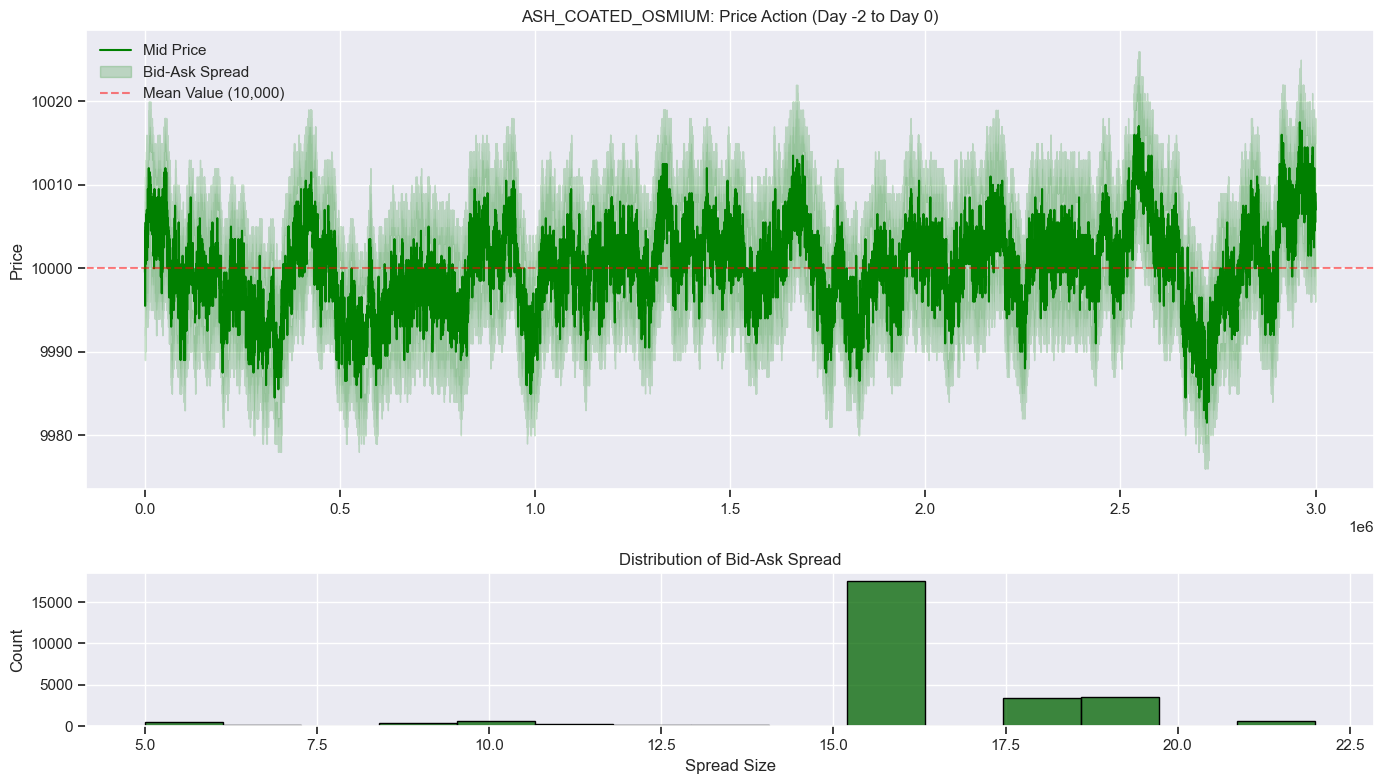

In [17]:
# ASH_COATED_OSMIUM
osmium_prices = valid_prices[valid_prices['product'] == 'ASH_COATED_OSMIUM']
osmium_trades = valid_prices[valid_prices['product'] == 'ASH_COATED_OSMIUM']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Plot 1: Price Timeline
ax1.plot(osmium_prices['global_timestamp'], osmium_prices['mid_price'], color='green', label='Mid Price', linewidth=1.5)
ax1.fill_between(osmium_prices['global_timestamp'], osmium_prices['bid_price_1'], osmium_prices['ask_price_1'], color='green', alpha=0.2, label='Bid-Ask Spread')
ax1.axhline(y=10000, color='red', linestyle='--', alpha=0.5, label='Mean Value (10,000)')
ax1.set_title('ASH_COATED_OSMIUM: Price Action (Day -2 to Day 0)')
ax1.set_ylabel('Price')
ax1.legend()

# Plot 2: Spread Distribution
sns.histplot(osmium_prices['spread'], bins=15, ax=ax2, color='darkgreen')
ax2.set_title('Distribution of Bid-Ask Spread')
ax2.set_xlabel('Spread Size')

plt.tight_layout()
plt.show()


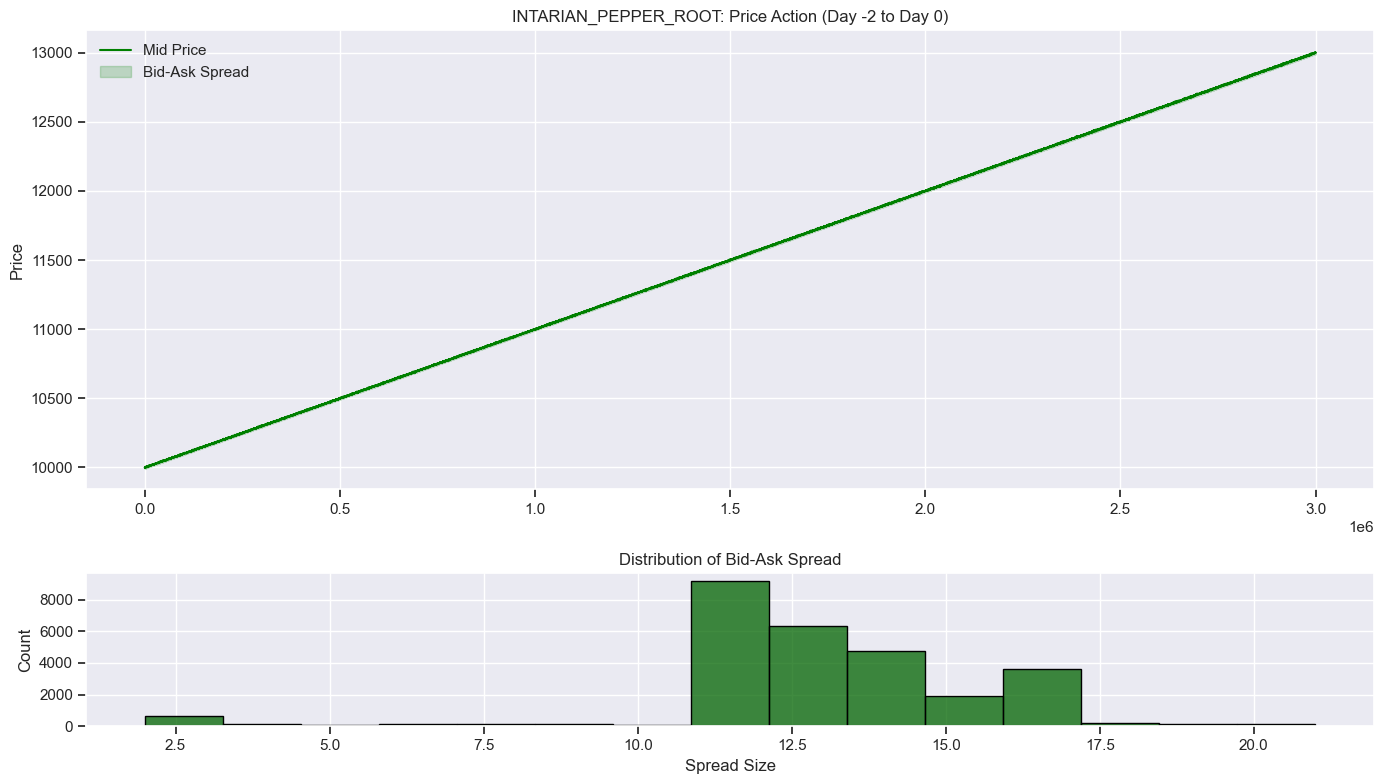

In [18]:
# INTARIAN_PEPPER_ROOT
pepper_prices = valid_prices[valid_prices['product'] == 'INTARIAN_PEPPER_ROOT']
pepper_trades = valid_prices[valid_prices['product'] == 'INTARIAN_PEPPER_ROOT']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Plot 1: Price Timeline
ax1.plot(pepper_prices['global_timestamp'], pepper_prices['mid_price'], color='green', label='Mid Price', linewidth=1.5)
ax1.fill_between(pepper_prices['global_timestamp'], pepper_prices['bid_price_1'], pepper_prices['ask_price_1'], color='green', alpha=0.2, label='Bid-Ask Spread')
ax1.set_title('INTARIAN_PEPPER_ROOT: Price Action (Day -2 to Day 0)')
ax1.set_ylabel('Price')
ax1.legend()

# Plot 2: Spread Distribution
sns.histplot(pepper_prices['spread'], bins=15, ax=ax2, color='darkgreen')
ax2.set_title('Distribution of Bid-Ask Spread')
ax2.set_xlabel('Spread Size')

plt.tight_layout()
plt.show()

`ASH_COATED_OSMIUM` stays clustered around a stable level near 10,000, with only modest fluctuations around that anchor. Its most common spreads are 16, then 19 and 18. That profile is consistent with a product suited to passive spread capture around a fixed fair value.

`INTARIAN_PEPPER_ROOT` behaves very differently. The price path shows clear within day drift together with distinct daily level shifts. The first modelling problem for Pepper Root is therefore not small step prediction in isolation, but correct estimation of the underlying fair value path.

### 2.3 Trade size and execution location relative to the books

The next question is whether trades occur at the displayed best bid and ask or whether they often print away from the visible book.

In [19]:
trade_stats = (
    trades.groupby('product')
    .agg(
        trade_rows=('price', 'size'),
        qty_mean=('quantity', 'mean'),
        qty_median=('quantity', 'median'),
        qty_max=('quantity', 'max'),
        price_mean=('price', 'mean'),
        price_min=('price', 'min'),
        price_max=('price', 'max'),
    )
    .round(4)
)

trade_stats

,trade_rows,qty_mean,qty_median,qty_max,price_mean,price_min,price_max
product,,,,,,,
ASH_COATED_OSMIUM,1265,5.2119,5.0,10,10000.2134,9979.0,10026.0
INTARIAN_PEPPER_ROOT,1011,5.1731,5.0,8,11495.9416,9995.0,13005.0


In [20]:
m = trades.merge(prices, on=master_key, how='left')

def loc(row):
    p = row['price']
    for level in [1, 2, 3]:
        bid = row.get(f'bid_price_{level}')
        ask = row.get(f'ask_price_{level}')
        if pd.notna(bid) and p == bid:
            return f'bid_{level}'
        if pd.notna(ask) and p == ask:
            return f'ask_{level}'
    return 'other'

m['book_loc'] = m.apply(loc, axis=1)

print(m['book_loc'].value_counts())
print()
print(m.groupby('product')['book_loc'].value_counts().unstack(fill_value=0))

book_loc
ask_1    1137
bid_1    1132
other       7
Name: count, dtype: int64

book_loc              ask_1  bid_1  other
product                                  
ASH_COATED_OSMIUM       647    618      0
INTARIAN_PEPPER_ROOT    490    514      7


Trade sizes are fairly similar across the two products, so the main structural difference does not come from execution size.

More importantly, almost all trades occur exactly at the best displayed bid or best displayed ask. That means the visible top of book captures most of the relevant execution environment and gives a credible basis for inferring simple trade direction later in the notebook.

## 3. Structural Price Behaviour and Fair Value Regime

Based on these initial diagnostics, the next step is to answer three structural questions:

1. Does `ASH_COATED_OSMIUM` behave like a product anchored around a fixed fair value?
2. Does `INTARIAN_PEPPER_ROOT` follow a deterministic time trend within each day?
3. After removing any obvious trend, how much residual noise remains?

### 3.1 Linear time trend fit

We first fit a simple linear model of the form

$$\text{mid price}_t = \alpha + \beta \cdot \text{timestamp}_t$$

to see whether time itself explains a material share of price variation within each day.

In [21]:
rows = []

for (product, day), g in valid_prices.groupby(['product', 'day']):
    x = g['timestamp'].values.astype(float)
    y = g['mid_price'].values.astype(float)

    slope, intercept = np.polyfit(x, y, 1)
    y_hat = intercept + slope * x

    ss_res = ((y - y_hat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    rows.append({
        'product': product,
        'day': day,
        'intercept': intercept,
        'slope_per_timeunit': slope,
        'r2': r2,
        'residual_std': np.std(y - y_hat),
        'mid_mean': y.mean(),
        'mid_std': y.std(),
    })

trend_fit = pd.DataFrame(rows).round(6)
trend_fit

,product,day,intercept,slope_per_timeunit,r2,residual_std,mid_mean,mid_std
0,ASH_COATED_OSMIUM,-2,9998.804335,-0.000001,0.006154,4.711444,9998.161750,4.726009
1,ASH_COATED_OSMIUM,-1,10001.232701,-0.000001,0.003643,3.818206,10000.833550,3.825179
2,ASH_COATED_OSMIUM,0,10000.879333,0.000001,0.006723,5.203971,10001.622563,5.221554
3,INTARIAN_PEPPER_ROOT,-2,9999.963591,0.001000,0.999985,1.123639,10500.567057,287.916809
4,INTARIAN_PEPPER_ROOT,-1,10999.947898,0.001000,0.999981,1.259512,11501.409155,287.624668
5,INTARIAN_PEPPER_ROOT,0,11999.984280,0.001000,0.999979,1.335130,12500.963093,288.176039


For `ASH_COATED_OSMIUM`, the estimated slope is essentially negligible on all three days. The linear fit explains almost none of the variation, with $R^2$ values of only about 0.0036 to 0.0067.

For `INTARIAN_PEPPER_ROOT`, the estimated slope is 0.001 on each day and the fit explains almost all of the variation, with $R^2$ essentially equal to 0.9999. In other words, Pepper Root does not simply trend upward in a loose sense. Its mid price follows an almost deterministic linear path within each day.

In [22]:
valid_prices['mid_change'] = valid_prices.groupby(['product', 'day'])['mid_price'].diff()

resid_frames = []
for (product, day), g in valid_prices.groupby(['product', 'day']):
    x = g['timestamp'].values.astype(float)
    y = g['mid_price'].values.astype(float)

    slope, intercept = np.polyfit(x, y, 1)
    resid = y - (intercept + slope * x)

    tmp = g[master_key].copy()
    tmp['trend_resid'] = resid
    resid_frames.append(tmp)

trend_resid = pd.concat(resid_frames, ignore_index=True)

valid_prices = valid_prices.merge(
    trend_resid,
    on=master_key,
    how='left'
)

valid_prices['resid_change'] = valid_prices.groupby(['product', 'day'])['trend_resid'].diff()

change_summary = []
for product, g in valid_prices.groupby('product'):
    mid_change = g['mid_change'].dropna()
    resid_change = g['resid_change'].dropna()

    change_summary.append({
        'product': product,
        'mid_change_mean': mid_change.mean(),
        'mid_change_std': mid_change.std(),
        'mid_change_lag1_autocorr': mid_change.autocorr(),
        'trend_resid_std': g['trend_resid'].std(),
        'resid_change_std': resid_change.std(),
        'resid_change_lag1_autocorr': resid_change.autocorr(),
    })

change_summary = pd.DataFrame(change_summary).round(6)
change_summary

,product,mid_change_mean,mid_change_std,mid_change_lag1_autocorr,trend_resid_std,resid_change_std,resid_change_lag1_autocorr
0,ASH_COATED_OSMIUM,0.000271,1.931897,-0.494323,4.613772,1.931897,-0.494323
1,INTARIAN_PEPPER_ROOT,0.108506,1.747328,-0.488202,1.242665,1.747017,-0.488250


This is a crucial result. Pepper Root is not a noisy product with a weak upward drift. It is a highly structured market whose fair value is dominated by a deterministic time component. The right modelling sequence is therefore to estimate fair value first and only then analyse deviations around that fair value.

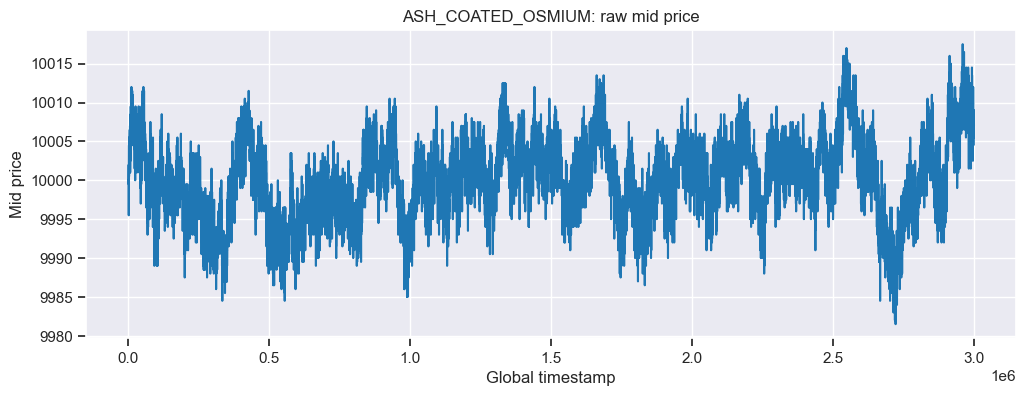

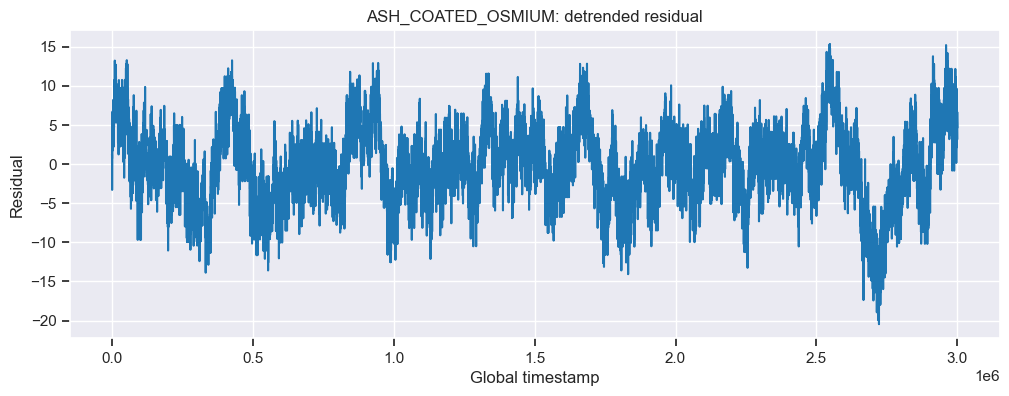

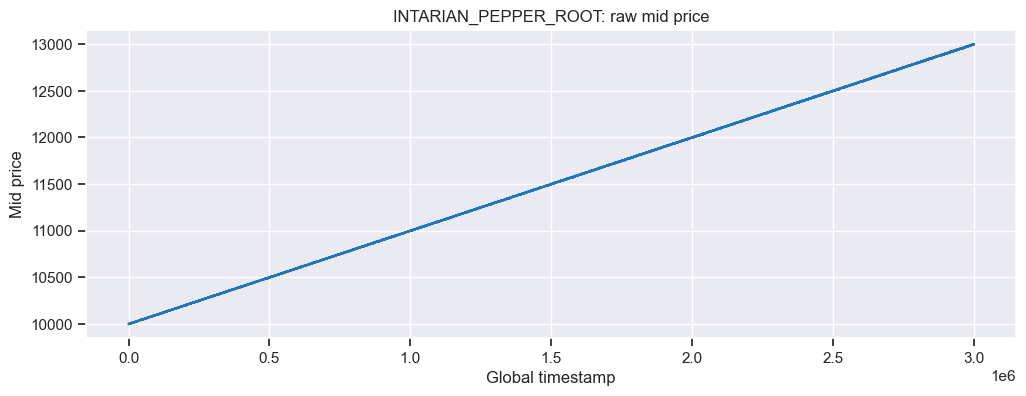

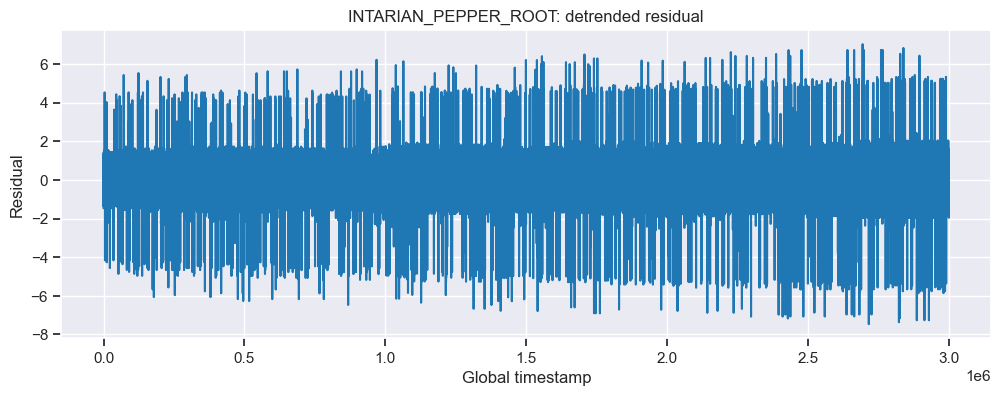

In [23]:
for product, g in valid_prices.groupby('product'):
    plt.figure(figsize=(12, 4))
    plt.plot(g['global_timestamp'], g['mid_price'])
    plt.title(f'{product}: raw mid price')
    plt.xlabel('Global timestamp')
    plt.ylabel('Mid price')
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(g['global_timestamp'], g['trend_resid'])
    plt.title(f'{product}: detrended residual')
    plt.xlabel('Global timestamp')
    plt.ylabel('Residual')
    plt.show()

For `ASH_COATED_OSMIUM`, detrending makes almost no difference because there was very little time trend to begin with. The raw series and the residual series tell the same story: fluctuations around a stable level.

For `INTARIAN_PEPPER_ROOT`, detrending changes the picture completely. The raw series looks highly non-stationary, but the residual series collapses into a narrow band around zero. That is exactly what we would expect if fair value is largely explained by a deterministic linear function of time.

### 3.2 Pepper Root base estimation

Pepper Root appears to follow

$$\text{mid}_t \approx \text{day base} + \frac{\text{timestamp}}{1000}$$

If that approximation is correct, then the quantity $\text{mid}_t - \frac{\text{timestamp}}{1000}$ should remain nearly constant within each day.

In [24]:
pepper = valid_prices[valid_prices['product'] == 'INTARIAN_PEPPER_ROOT'].copy()
pepper['base_est'] = pepper['mid_price'] - pepper['timestamp'] / 1000.0

pepper_base_summary = (
    pepper.groupby('day')['base_est']
    .agg(['mean', 'std', 'min', 'max'])
    .round(6)
)

pepper_base_summary

,mean,std,min,max
day,,,,
-2,9999.970508,1.123707,9993.5,10006.2
-1,10999.986636,1.259776,10993.1,11006.5
0,11999.973284,1.335217,11992.5,12007.0


That is exactly what the data shows. The within day base estimates differ by roughly 1,000 across the three days and have a very small standard deviation, around 1.12 to 1.34. A practical description of Pepper Root fair value is therefore

- day -2: 10000 + timestamp / 1000
- day -1: 11000 + timestamp / 1000
- day 0: 12000 + timestamp / 1000

or, equivalently by construction, 10000 + global_timestamp / 1000.

In [25]:
pepper['base_round'] = pepper['base_est'].round()

(
    pepper.groupby(['day', 'base_round'])
    .size()
    .reset_index(name='n')
    .sort_values(['day', 'n'], ascending=[True, False])
    .groupby('day')
    .head(5)
)

,day,base_round,n
6,-2,10000.0,6351
7,-2,10001.0,900
5,-2,9999.0,884
4,-2,9998.0,405
8,-2,10002.0,353
20,-1,11000.0,6306
22,-1,11002.0,648
18,-1,10998.0,647
19,-1,10999.0,632
21,-1,11001.0,628


The modal rounded base on each day matches the linear trend result exactly:

- day -2: 10000
- day -1: 11000
- day 0: 12000

That agreement between two separate views of the data gives confidence that the fair value model is capturing the true regime rather than overfitting noise.

For live trading, a practical first pass fair value model for Pepper Root is therefore

$$\text{fair}_t = \text{day base} + \frac{\text{global timestamp}}{1000}$$

with the day base inferred from observed prices. The important point is that Pepper should be traded relative to this moving fair value, not relative to a static anchor.

### 3.3 Osmium base estimation

We begin with deviations from 10,000, which is the obvious candidate anchor for Osmium.

In [26]:
osmium = valid_prices[valid_prices['product'] == 'ASH_COATED_OSMIUM'].copy()
osmium['dev_10000'] = osmium['mid_price'] - 10000

anchor_summary = pd.Series({
    'mean_deviation': osmium['dev_10000'].mean(),
    'std_deviation': osmium['dev_10000'].std(),
    'pct_within_5': (osmium['dev_10000'].abs() <= 5).mean(),
    'pct_within_10': (osmium['dev_10000'].abs() <= 10).mean(),
    'pct_within_15': (osmium['dev_10000'].abs() <= 15).mean(),
}).round(6)

anchor_summary

mean_deviation    0.209123
std_deviation     4.858191
pct_within_5      0.736290
pct_within_10     0.966322
pct_within_15     0.998951
dtype: float64

Across the full valid sample:

- the mean deviation from 10,000 is about 0.209
- the standard deviation is about 4.858
- about 73.6% of observations lie within 5 ticks of 10,000
- about 96.6% lie within 10 ticks
- about 99.9% lie within 15 ticks

This is very strong evidence that 10,000 is the correct first pass fair value anchor for Osmium. A fixed anchor already explains most of the economically relevant structure.

We then examine mid price changes and residual behaviour after removing the fitted daily linear trend. This is mainly a sanity check: if Osmium truly has no meaningful trend, detrending should not materially change its behaviour.

In [27]:
valid_prices['mid_change'] = valid_prices.groupby(['product', 'day'])['mid_price'].diff()

resid_frames = []
for (product, day), g in valid_prices.groupby(['product', 'day']):
    x = g['timestamp'].values.astype(float)
    y = g['mid_price'].values.astype(float)

    slope, intercept = np.polyfit(x, y, 1)
    resid = y - (intercept + slope * x)

    tmp = g[master_key].copy()
    tmp['trend_resid'] = resid
    resid_frames.append(tmp)

trend_resid = pd.concat(resid_frames, ignore_index=True)

valid_prices = valid_prices.merge(
    trend_resid,
    on=master_key,
    how='left'
)

valid_prices['resid_change'] = valid_prices.groupby(['product', 'day'])['trend_resid'].diff()

change_summary = []
for product, g in valid_prices.groupby('product'):
    mid_change = g['mid_change'].dropna()
    resid_change = g['resid_change'].dropna()

    change_summary.append({
        'product': product,
        'mid_change_mean': mid_change.mean(),
        'mid_change_std': mid_change.std(),
        'mid_change_lag1_autocorr': mid_change.autocorr(),
        'trend_resid_std': g['trend_resid'].std(),
        'resid_change_std': resid_change.std(),
        'resid_change_lag1_autocorr': resid_change.autocorr(),
    })

change_summary = pd.DataFrame(change_summary).round(6)
change_summary

KeyError: 'Column not found: trend_resid'

## 4. Microstructure Signals Relative to Fair Value

The goal of this phase is to test short horizon microstructure signals relative to the correct price regime for each product. In particular, we want to know whether:

- level 1 imbalance helps predict the next mid price change
- deeper imbalance adds anything beyond level 1
- microprice contains useful directional information
- deviations from the fair value model predict reversion or continuation

### 4.1 Construct signal variables and prediction target

In [28]:
valid_prices = valid_prices.sort_values(master_key).copy()

valid_prices['next_mid'] = valid_prices.groupby(['product', 'day'])['mid_price'].shift(-1)
valid_prices['next_mid_change'] = valid_prices['next_mid'] - valid_prices['mid_price']

valid_prices['micro_l1'] = (
    valid_prices['ask_price_1'] * valid_prices['bid_volume_1']
    + valid_prices['bid_price_1'] * valid_prices['ask_volume_1']
) / (valid_prices['bid_volume_1'] + valid_prices['ask_volume_1'])

valid_prices['micro_l1_prem'] = valid_prices['micro_l1'] - valid_prices['mid_price']

num = (
    valid_prices['ask_price_1'] - valid_prices['bid_volume_1']
    + valid_prices['bid_price_1'] - valid_prices['ask_volume_1']
)
den = valid_prices['bid_volume_1'] + valid_prices['ask_volume_1']

num = num + np.where(
    valid_prices['bid_price_2'].notna() & valid_prices['bid_volume_2'].fillna(0).gt(0),
    valid_prices['ask_price_2'] * valid_prices['bid_volume_2'],
    0
)

num = num + np.where(
    valid_prices['ask_price_2'].notna() & valid_prices['ask_volume_2'].fillna(0).gt(0),
    valid_prices['bid_price_2'] * valid_prices['ask_volume_2'],
    0
)

den = den + np.where(
    valid_prices['bid_price_2'].notna() & valid_prices['bid_volume_2'].fillna(0).gt(0),
    valid_prices['bid_volume_2'],
    0
)

den = den + np.where(
    valid_prices['ask_price_2'].notna() & valid_prices['ask_volume_2'].fillna(0).gt(0),
    valid_prices['ask_volume_2'],
    0
)

valid_prices['micro_l2'] = num / den
valid_prices['micro_l2_prem'] = valid_prices['micro_l2'] - valid_prices['mid_price']

valid_prices['fair'] = np.nan
valid_prices.loc[valid_prices['product'] == 'ASH_COATED_OSMIUM', 'fair'] = 10000.0

pep = valid_prices[valid_prices['product'] == 'INTARIAN_PEPPER_ROOT'].copy()
base_by_day = (
    (pep['mid_price'] - pep['timestamp'] / 1000.0)
    .groupby(pep['day'])
    .median()
    .round()
)

for d, b in base_by_day.items():
    mask = (
        (valid_prices['product'] == 'INTARIAN_PEPPER_ROOT')
        & (valid_prices['day'] == d)
    )
    valid_prices.loc[mask, 'fair'] = b + valid_prices.loc[mask, 'timestamp'] / 1000.0

valid_prices['fair_prem'] = valid_prices['fair'] - valid_prices['mid_price']

### 4.2 Correlation of candidate signals with next mid-price change

We start by comparing the correlation of each candidate signal with the next mid price change. This is not enough on its own to design a strategy, but it gives a clear first ranking of which variables deserve further attention.

In [29]:
rows = []

for product, g in valid_prices.groupby('product'):
    gg = g.dropna(subset=['next_mid_change']).copy()

    for feature in [
        'imbalance_l1',
        'imbalance_l2',
        'imbalance_l3',
        'micro_l1_prem',
        'micro_l2_prem',
        'fair_prem'
    ]:
        tmp = gg[[feature, 'next_mid_change']].dropna().copy()

        corr = tmp[feature].corr(tmp['next_mid_change'])

        nz = tmp[(tmp[feature] != 0) & (tmp['next_mid_change'] != 0)]
        sign_acc = (
            (np.sign(nz[feature]) == np.sign(nz['next_mid_change'])).mean()
            if len(nz) > 0 else np.nan
        )

        rows.append({
            'product': product,
            'feature': feature,
            'corr_next_mid_change': corr,
            'sign_acc_nonzero': sign_acc,
            'coverage_nonzero': len(nz) / len(tmp) if len(tmp) > 0 else np.nan,
        })

signal_summary = pd.DataFrame(rows).round(6)
signal_summary

,product,feature,corr_next_mid_change,sign_acc_nonzero,coverage_nonzero
0,ASH_COATED_OSMIUM,imbalance_l1,0.586725,0.934200,0.317246
1,ASH_COATED_OSMIUM,imbalance_l2,0.087888,0.424361,0.424731
2,ASH_COATED_OSMIUM,imbalance_l3,-0.076392,0.326750,0.424948
3,ASH_COATED_OSMIUM,micro_l1_prem,0.499348,0.934200,0.317246
4,ASH_COATED_OSMIUM,micro_l2_prem,0.006767,0.497388,0.627717
5,ASH_COATED_OSMIUM,fair_prem,0.198796,0.582335,0.636916
6,INTARIAN_PEPPER_ROOT,imbalance_l1,0.562977,0.954208,0.282391
7,INTARIAN_PEPPER_ROOT,imbalance_l2,-0.000246,0.366383,0.382518
8,INTARIAN_PEPPER_ROOT,imbalance_l3,-0.109976,0.303876,0.382987
9,INTARIAN_PEPPER_ROOT,micro_l1_prem,0.457163,0.954208,0.282391


Three points stand out immediately.

**1. Level 1 imbalance works, deeper imbalance does not.**

For both products, `imbalance_l1` is meaningfully informative, while `imbalance_l2` and `imbalance_l3` are weak and in places misleading. That suggests the useful information is concentrated at the top of the book rather than deeper in the queue.

**2. Microprice is useful, especially when two levels are included.**

For both products, `micro_l1_prem` is informative and `micro_l2_prem` is even stronger. Weighted quote information therefore captures something that raw depth totals miss.

**3. Fair value deviations matter far more for Pepper Root than for Osmium.**

For Osmium, `fair_prem` is only moderately related to the next move. For Pepper Root, `fair_prem` is the strongest feature in the table, with correlation of about 0.703. Once Pepper is measured relative to its proper linear fair value path, deviations from that path become highly informative about the next mid price move.

### 4.3. Sign-based directional check

Correlation is useful, but it is also helpful to ask a simpler directional question: when a signal is non-zero, does its sign usually match the sign of the next mid price change?

In [30]:
signal_summary[['product', 'feature', 'sign_acc_nonzero', 'coverage_nonzero']]

,product,feature,sign_acc_nonzero,coverage_nonzero
0,ASH_COATED_OSMIUM,imbalance_l1,0.934200,0.317246
1,ASH_COATED_OSMIUM,imbalance_l2,0.424361,0.424731
2,ASH_COATED_OSMIUM,imbalance_l3,0.326750,0.424948
3,ASH_COATED_OSMIUM,micro_l1_prem,0.934200,0.317246
4,ASH_COATED_OSMIUM,micro_l2_prem,0.497388,0.627717
5,ASH_COATED_OSMIUM,fair_prem,0.582335,0.636916
6,INTARIAN_PEPPER_ROOT,imbalance_l1,0.954208,0.282391
7,INTARIAN_PEPPER_ROOT,imbalance_l2,0.366383,0.382518
8,INTARIAN_PEPPER_ROOT,imbalance_l3,0.303876,0.382987
9,INTARIAN_PEPPER_ROOT,micro_l1_prem,0.954208,0.282391


The directional check reinforces the earlier ranking. Some of the hit rates are very high, especially for level 1 signals.

These values are inflated somewhat by conditioning on non-zero events and by less than full coverage, but the ordering still matters. The main lessons are clear:

- level 1 order book pressure is highly informative when it is present
- for Pepper Root, fair value deviation is also strongly directionally useful
- deeper imbalance again fails to justify a central role in the strategy

### 4.4 Average next move by imbalance regime

To move from correlation to trading intuition, we bucket level 1 imbalance and look at the average next mid price change in each regime.

In [31]:
for product, g in valid_prices.groupby('product'):
    gg = g.dropna(subset=['next_mid_change', 'imbalance_l1']).copy()
    gg['imb_bucket'] = pd.qcut(gg['imbalance_l1'], q=10, duplicates='drop')

    bucket_summary = (
        gg.groupby('imb_bucket', observed=False)['next_mid_change']
        .mean()
    )

    print(product)
    print(bucket_summary)
    print()

ASH_COATED_OSMIUM
imb_bucket
(-0.876, -0.333]   -2.037551
(-0.333, 0.0]      -0.144024
(0.0, 0.333]        1.627277
(0.333, 0.909]      2.182000
Name: next_mid_change, dtype: float64

INTARIAN_PEPPER_ROOT
imb_bucket
(-0.787, -0.29]   -1.716114
(-0.29, 0.0]      -0.029842
(0.0, 0.29]        1.952111
(0.29, 0.833]      1.908894
Name: next_mid_change, dtype: float64



The imbalance buckets show a clean monotonic pattern for both products.

For `ASH_COATED_OSMIUM`, strongly negative imbalance is associated with average next moves around -2.04, mildly negative imbalance is near flat and positive imbalance is associated with moves around +1.63 to +2.18.

For `INTARIAN_PEPPER_ROOT`, strongly negative imbalance is associated with moves around -1.72, mildly negative imbalance is again near zero and positive imbalance is associated with moves around +1.91 to +1.95.

This matters because it turns imbalance from a descriptive statistic into a plausible trading trigger. When top of book pressure becomes meaningfully one sided, the next move tends to follow the same direction.

### 4.5 Direction of next move conditional on signal sign

In [32]:
cond_rows = []

for product, g in valid_prices.groupby('product'):
    gg = g.dropna(subset=['next_mid_change', 'fair_prem', 'imbalance_l1', 'micro_l1_prem']).copy()

    for feature in ['fair_prem', 'imbalance_l1', 'micro_l1_prem']:
        for label, mask in [('pos', gg[feature] > 0), ('neg', gg[feature] < 0)]:
            sub = gg[mask]
            cond_rows.append({
                'product': product,
                'feature': feature,
                'sign': label,
                'mean_next_mid_change': sub['next_mid_change'].mean(),
                'n': len(sub),
            })

cond_summary = pd.DataFrame(cond_rows).round(6)
cond_summary

,product,feature,sign,mean_next_mid_change,n
0,ASH_COATED_OSMIUM,fair_prem,pos,0.329869,11788
1,ASH_COATED_OSMIUM,fair_prem,neg,-0.304744,14061
2,ASH_COATED_OSMIUM,imbalance_l1,pos,1.929677,4586
3,ASH_COATED_OSMIUM,imbalance_l1,neg,-1.874171,4673
4,ASH_COATED_OSMIUM,micro_l1_prem,pos,1.929677,4586
5,ASH_COATED_OSMIUM,micro_l1_prem,neg,-1.874171,4673
6,INTARIAN_PEPPER_ROOT,fair_prem,pos,0.846151,12041
7,INTARIAN_PEPPER_ROOT,fair_prem,neg,-0.630061,11856
8,INTARIAN_PEPPER_ROOT,imbalance_l1,pos,1.924650,4353
9,INTARIAN_PEPPER_ROOT,imbalance_l1,neg,-1.679336,4249


This confirms the earlier picture.

For Osmium, imbalance is stronger than anchor deviation as a short horizon signal. For Pepper Root, both imbalance and fair value deviation are useful, but fair value deviation is the more structurally important feature because it reflects the product's underlying price regime rather than only instantaneous book pressure.

### 4.6 Conclusions

The evidence from this phase leads to five clear conclusions.

**A. Level 1 order book pressure is genuinely useful.**  
For both products, `imbalance_l1` is strongly associated with the next mid price change. The relationship is monotonic and directionally consistent, which makes it a credible short horizon signal.

**B. Deeper imbalance adds little.**  
`imbalance_l2` and `imbalance_l3` perform poorly for both products, so deeper raw depth should not be a core part of the final model.

**C. Microprice is useful.**  
Both `micro_l1_prem` and especially `micro_l2_prem` contain signal. Weighted quote information matters even though deeper imbalance by itself does not.

**D. Pepper Root should be traded relative to fair value.**  
For `INTARIAN_PEPPER_ROOT`, `fair_prem` is the strongest feature in the whole phase. The strategy should therefore be built primarily around deviations from the linear fair value path, with microstructure features used mainly for timing.

**E. Osmium should be traded around an anchor, but with microstructure support.**  
For `ASH_COATED_OSMIUM`, the fixed 10,000 anchor is useful context, but it is not sufficient on its own. The more important short term edge comes from level 1 imbalance and microprice.

The strategy ingredients suggested by this phase are therefore:

`ASH_COATED_OSMIUM`

- fair value anchor at 10,000
- level 1 imbalance or microprice to lean quotes
- passive market making with inventory control
- selective taking when the quote is far from anchor and book pressure agrees

`INTARIAN_PEPPER_ROOT`

- fair value estimated as base + timestamp / 1000
- more aggressive trading when market price deviates from that fair value
- imbalance or microprice used mainly to improve entry timing and quote placement
- inventory control still matters, but the core edge comes from fair value deviation

## 5. Trade Behaviour and Execution Informativeness

### 5.1 Map trades to execution side

Since almost all trades occur at the best displayed bid or ask, we infer a simple trade sign:

- +1 if the trade occurs at the ask, interpreted as aggressive buying
- -1 if the trade occurs at the bid, interpreted as aggressive selling
- 0 otherwise

In [33]:
m = trades.merge(
    prices[
        [
            'global_timestamp', 'product', 'day', 'timestamp',
            'mid_price', 'bid_price_1', 'ask_price_1',
            'bid_price_2', 'ask_price_2', 'bid_price_3', 'ask_price_3',
            'spread'
        ]
    ],
    on=['global_timestamp', 'product', 'day', 'timestamp'],
    how='left'
)

def loc(row):
    p = row['price']
    for level in [1, 2, 3]:
        bid = row.get(f'bid_price_{level}')
        ask = row.get(f'ask_price_{level}')
        if pd.notna(bid) and p == bid:
            return f'bid_{level}'
        if pd.notna(ask) and p == ask:
            return f'ask_{level}'
    return 'other'

m['book_loc'] = m.apply(loc, axis=1)

m['trade_sign'] = np.where(
    m['book_loc'].str.startswith('ask'),
    1,
    np.where(m['book_loc'].str.startswith('bid'), -1, 0)
)

m = m.merge(
    valid_prices[
        [
            'global_timestamp', 'product', 'day', 'timestamp',
            'next_mid_change', 'fair_prem', 'imbalance_l1', 'mid_price', 'fair'
        ]
    ],
    on=['global_timestamp', 'product', 'day', 'timestamp'],
    how='left',
    suffixes=('', '_vp')
)

m.head()

,timestamp,buyer,seller,product,currency,price,quantity,day,global_timestamp,mid_price,...,bid_price_3,ask_price_3,spread,book_loc,trade_sign,next_mid_change,fair_prem,imbalance_l1,mid_price_vp,fair
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6,-2,700,10000.5,...,NaN,NaN,21.0,bid_1,-1,1.5,-0.5,0.000000,10000.5,10000.0
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2,-2,900,9995.5,...,NaN,10011.0,5.0,ask_1,1,4.0,4.5,0.238095,9995.5,10000.0
2,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7,-2,1000,10000.5,...,NaN,NaN,11.0,bid_1,-1,-0.5,0.5,0.000000,10000.5,10001.0
3,2500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10011.0,8,-2,2500,10001.5,...,NaN,NaN,19.0,ask_1,1,1.5,-1.5,0.200000,10001.5,10000.0
4,4000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10007.0,7,-2,4000,10008.5,...,9996.0,NaN,3.0,bid_1,-1,-4.5,-4.5,-0.222222,10008.5,10004.0


This is not a perfect reconstruction of hidden market order flow, but in this dataset it is a reasonable approximation because nearly all trades occur exactly at the best bid or best ask.

### 5.2 Does trade direction predict the next move?

We now ask a simple question: if the last observed trade at a timestamp is buyer initiated or seller initiated, does that contain useful information about the next mid price change?

In [34]:
trade_sig = m.dropna(subset=['next_mid_change']).copy()

rows = []
for product, g in trade_sig.groupby('product'):
    tmp = g[g['trade_sign'] != 0].copy()

    corr = tmp['trade_sign'].corr(tmp['next_mid_change'])
    sign_acc = (np.sign(tmp['trade_sign']) == np.sign(tmp['next_mid_change'])).mean()

    rows.append({
        'product': product,
        'n': len(tmp),
        'corr_trade_sign_next_mid_change': corr,
        'sign_acc': sign_acc,
        'mean_next_mid_if_buy': tmp.loc[tmp['trade_sign'] > 0, 'next_mid_change'].mean(),
        'mean_next_mid_if_sell': tmp.loc[tmp['trade_sign'] < 0, 'next_mid_change'].mean(),
    })

trade_sign_summary = pd.DataFrame(rows).round(6)
trade_sign_summary

,product,n,corr_trade_sign_next_mid_change,sign_acc,mean_next_mid_if_buy,mean_next_mid_if_sell
0,ASH_COATED_OSMIUM,1229,0.075713,0.355574,0.198248,-0.100666
1,INTARIAN_PEPPER_ROOT,963,0.463390,0.492212,1.838675,-1.082828


For Osmium, individual trade direction is not a strong predictor. Realised trades appear much less informative than the displayed book.

For Pepper Root, trade direction does contain information, but it is still weaker than fair value deviation and weaker than the best book based signals from the previous phase. That makes trade flow a possible refinement, not the foundation of the strategy.

### 5.3 Compare trade-flow variables to the next mid-price change

We next compare several trade based variables against the next move:

- `signed_trade_count`
- `signed_trade_volume`
- `trade_prem_to_mid`
- `trade_prem_to_fair`

We include `imbalance_l1` and `fair_prem` as benchmarks so that trade flow can be judged against the strongest signals already identified.

In [35]:
agg = (
    m.groupby(['global_timestamp', 'product', 'day', 'timestamp'])
    .apply(lambda g: pd.Series({
        'trade_count': len(g),
        'trade_volume': g['quantity'].sum(),
        'signed_trade_volume': (g['quantity'] * g['trade_sign']).sum(),
        'signed_trade_count': g['trade_sign'].sum(),
        'trade_vwap': np.average(g['price'], weights=g['quantity']),
        'mid_price': g['mid_price_vp'].iloc[0],
        'next_mid_change': g['next_mid_change'].iloc[0],
        'fair': g['fair'].iloc[0],
        'fair_prem': g['fair_prem'].iloc[0],
        'imbalance_l1': g['imbalance_l1'].iloc[0],
        'spread': g['spread'].iloc[0],
    }))
    .reset_index()
)

agg['trade_prem_to_mid'] = agg['trade_vwap'] - agg['mid_price']
agg['trade_prem_to_fair'] = agg['trade_vwap'] - agg['fair']

agg.head()

,global_timestamp,product,day,timestamp,trade_count,trade_volume,signed_trade_volume,signed_trade_count,trade_vwap,mid_price,next_mid_change,fair,fair_prem,imbalance_l1,spread,trade_prem_to_mid,trade_prem_to_fair
0,700,ASH_COATED_OSMIUM,-2,700,1.0,6.0,-6.0,-1.0,9990.0,10000.5,1.5,10000.0,-0.5,0.000000,21.0,-10.5,-10.0
1,900,ASH_COATED_OSMIUM,-2,900,1.0,2.0,2.0,1.0,9998.0,9995.5,4.0,10000.0,4.5,0.238095,5.0,2.5,-2.0
2,1000,INTARIAN_PEPPER_ROOT,-2,1000,1.0,7.0,-7.0,-1.0,9995.0,10000.5,-0.5,10001.0,0.5,0.000000,11.0,-5.5,-6.0
3,2500,ASH_COATED_OSMIUM,-2,2500,1.0,8.0,8.0,1.0,10011.0,10001.5,1.5,10000.0,-1.5,0.200000,19.0,9.5,11.0
4,4000,INTARIAN_PEPPER_ROOT,-2,4000,1.0,7.0,-7.0,-1.0,10007.0,10008.5,-4.5,10004.0,-4.5,-0.222222,3.0,-1.5,3.0


In [36]:
rows = []

for product, g in agg.dropna(subset=['next_mid_change']).groupby('product'):
    for feature in [
        'signed_trade_count',
        'signed_trade_volume',
        'trade_prem_to_mid',
        'trade_prem_to_fair',
        'imbalance_l1',
        'fair_prem'
    ]:
        tmp = g[[feature, 'next_mid_change']].dropna().copy()

        corr = tmp[feature].corr(tmp['next_mid_change'])

        nz = tmp[(tmp[feature] != 0) & (tmp['next_mid_change'] != 0)]
        sign_acc = (
            (np.sign(nz[feature]) == np.sign(nz['next_mid_change'])).mean()
            if len(nz) > 0 else np.nan
        )

        rows.append({
            'product': product,
            'feature': feature,
            'corr_next_mid_change': corr,
            'sign_acc_nonzero': sign_acc,
            'coverage_nonzero': len(nz) / len(tmp) if len(tmp) > 0 else np.nan,
        })

trade_feature_summary = pd.DataFrame(rows).round(6)
trade_feature_summary

,product,feature,corr_next_mid_change,sign_acc_nonzero,coverage_nonzero
0,ASH_COATED_OSMIUM,signed_trade_count,0.076043,0.531288,0.670230
1,ASH_COATED_OSMIUM,signed_trade_volume,0.042074,0.529915,0.673520
2,ASH_COATED_OSMIUM,trade_prem_to_mid,0.044711,0.529915,0.673520
3,ASH_COATED_OSMIUM,trade_prem_to_fair,-0.061709,0.490613,0.657072
4,ASH_COATED_OSMIUM,imbalance_l1,0.630789,0.964912,0.328125
5,ASH_COATED_OSMIUM,fair_prem,0.201477,0.587933,0.640625
6,INTARIAN_PEPPER_ROOT,signed_trade_count,0.464988,0.697329,0.698446
7,INTARIAN_PEPPER_ROOT,signed_trade_volume,0.461833,0.696746,0.700518
8,INTARIAN_PEPPER_ROOT,trade_prem_to_mid,0.138879,0.697947,0.706736
9,INTARIAN_PEPPER_ROOT,trade_prem_to_fair,-0.319317,0.290323,0.706736


For Osmium, all trade based features are weak. They are clearly dominated by `imbalance_l1`, and even the fixed anchor premium is more informative than signed trade flow. The displayed book appears to reveal more than realised prints.

For Pepper Root, signed trade count and signed trade volume are materially informative, but even there they are still weaker than the two leading signals: `fair_prem` and `imbalance_l1`. The trade tape contains some timing information, but it does not overturn the earlier conclusion that the strategy should be fair value led and book led.

### 5.5 Do trades confirm the book and fair-value signals?

It is also useful to know whether aggressive trades typically confirm the book and fair value signals, or whether they often move against them.

In [37]:
rows = []

for product, g in agg.groupby('product'):
    gg = g.dropna(subset=['signed_trade_count', 'imbalance_l1', 'fair_prem']).copy()

    trade_side = np.sign(gg['signed_trade_count'])
    imb_side = np.sign(gg['imbalance_l1'])
    fair_side = np.sign(gg['fair_prem'])

    rows.append({
        'product': product,
        'trade_vs_imbalance_agreement': (trade_side[trade_side != 0] == imb_side[trade_side != 0]).mean(),
        'trade_vs_fair_agreement': (trade_side[trade_side != 0] == fair_side[trade_side != 0]).mean(),
        'n_nonzero_trade_side': (trade_side != 0).sum(),
    })

agreement_summary = pd.DataFrame(rows).round(6)
agreement_summary

,product,trade_vs_imbalance_agreement,trade_vs_fair_agreement,n_nonzero_trade_side
0,ASH_COATED_OSMIUM,0.185277,0.486352,1209
1,INTARIAN_PEPPER_ROOT,0.376176,0.592476,957


The evidence suggests that aggressive trades are not simply echoing the strongest book signals. In many cases they look reactive rather than leading, which helps explain why trade side variables are weaker than the displayed book in Osmium.

For Pepper Root, trade flow may still add some timing value, but it does not appear to be the structural source of edge. The market seems to reveal more through deviations from fair value and top of book pressure than through the last realised print.

### 5.6 What does a trade at a premium or discount mean?

A final trade based question is whether trading above or below the current mid price or fair value carries useful information about the next move.

In [38]:
for product, g in agg.groupby('product'):
    gg = g.dropna(subset=['trade_prem_to_mid', 'trade_prem_to_fair', 'next_mid_change']).copy()

    print(product)
    print('trade premium to mid correlation:', gg['trade_prem_to_mid'].corr(gg['next_mid_change']))
    print('trade premium to fair correlation:', gg['trade_prem_to_fair'].corr(gg['next_mid_change']))
    print()

ASH_COATED_OSMIUM
trade premium to mid correlation: 0.0447113983812626
trade premium to fair correlation: -0.061709312607164814

INTARIAN_PEPPER_ROOT
trade premium to mid correlation: 0.1388789828381019
trade premium to fair correlation: -0.31931683731544813



For `ASH_COATED_OSMIUM`, trade premium to mid has only a very weak positive relationship with the next move and trade premium to fair is essentially not useful.

For `INTARIAN_PEPPER_ROOT`, trade premium to mid is still weak, while trade premium to fair is meaningfully negative at about -0.319. That makes economic sense. If trades occur far above fair value in Pepper Root, the next move is less likely to continue upward because the market is already rich relative to its deterministic fair value path. In that sense, trade price relative to fair behaves more like a mean reversion flag than a continuation signal.

### 5.7 Conclusions

This phase leads to five conclusions.

**A. Trades are not the primary source of signal.**  
For both products, trade based variables are weaker than the best book based variables. The displayed book still contains the most useful short horizon information.

**B. Osmium should not rely on trade flow.**  
For `ASH_COATED_OSMIUM`, trade direction and signed trade volume are very weak predictors. The core edge still comes from the anchor and level 1 book pressure.

**C. Pepper Root trade flow is informative, but secondary.**  
For `INTARIAN_PEPPER_ROOT`, signed trade flow carries some information, but it is still dominated by fair value deviation and level 1 imbalance.

**D. Trades often react rather than lead.**  
Aggressive trade side does not consistently align with imbalance or fair value signals, especially in Osmium. Realised trades often look like liquidity taking responses rather than the cleanest leading indicator.

**E. Strategy implication.**  
The strategy should remain book led rather than trade led. For Osmium, use the 10,000 anchor and level 1 pressure. For Pepper Root, use the linear fair value path first, level 1 imbalance second and trade flow only as an optional refinement.

## 6. Execution

### 6.1 How profitable are different aggressive-buy / aggressive-sell thresholds?

We now turn from signal discovery to execution design. The key question is how strong a quote edge needs to be before aggressive trading is justified, and whether those thresholds differ across the two products.

In [39]:
pepper = valid_prices[valid_prices['product'] == 'INTARIAN_PEPPER_ROOT'].copy()
pepper['base_est'] = pepper['mid_price'] - pepper['timestamp'] / 1000.0

pepper.groupby('day')['base_est'].agg(['mean', 'std', 'min', 'max']).round(6)

,mean,std,min,max
day,,,,
-2,9999.970508,1.123707,9993.5,10006.2
-1,10999.986636,1.259776,10993.1,11006.5
0,11999.973284,1.335217,11992.5,12007.0


In [40]:
valid_prices['edge_buy_vs_ask'] = valid_prices['fair'] - valid_prices['ask_price_1']
valid_prices['edge_sell_vs_bid'] = valid_prices['bid_price_1'] - valid_prices['fair']

edge_summary = (
    valid_prices.groupby('product')[['edge_buy_vs_ask', 'edge_sell_vs_bid']]
    .describe()
    .round(4)
)

edge_summary

edge_buy_vs_ask                                        \
                               count    mean     std   min   25%  50%  75%   
product                                                                      
ASH_COATED_OSMIUM            27644.0 -8.2967  5.0665 -26.0 -12.0 -9.0 -5.0   
INTARIAN_PEPPER_ROOT         27688.0 -6.5002  1.8735 -10.7  -6.9 -6.4 -5.9   

                           edge_sell_vs_bid                                   \
                       max            count    mean     std   min   25%  50%   
product                                                                        
ASH_COATED_OSMIUM     16.0          27644.0 -7.8785  4.9840 -24.0 -11.0 -8.0   
INTARIAN_PEPPER_ROOT   4.8          27688.0 -6.5465  1.7407 -10.7  -6.9 -6.4   

                                 
                      75%   max  
product                          
ASH_COATED_OSMIUM    -5.0  14.0  
INTARIAN_PEPPER_ROOT -5.9   3.8

In [41]:
rows = []

for product, g in valid_prices.dropna(subset=['next_mid_change']).groupby('product'):
    for t in [0.5, 1, 1.5, 2, 2.5, 3, 4]:
        sub = g[g['edge_buy_vs_ask'] >= t]
        rows.append({
            'product': product,
            'threshold': t,
            'n': len(sub),
            'mean_next_mid_change': sub['next_mid_change'].mean()
        })

buy_edge_table = pd.DataFrame(rows).round(6)
buy_edge_table.pivot_table(index=['product','threshold'], values=['n', 'mean_next_mid_change'])

mean_next_mid_change       n
product              threshold                              
ASH_COATED_OSMIUM    0.5                    1.591503  1377.0
                     1.0                    1.591503  1377.0
                     1.5                    1.921492   898.0
                     2.0                    1.921492   898.0
                     2.5                    2.707585   501.0
                     3.0                    2.707585   501.0
                     4.0                    3.419697   330.0
INTARIAN_PEPPER_ROOT 0.5                    5.338608   474.0
                     1.0                    5.338608   474.0
                     1.5                    5.338608   474.0
                     2.0                    5.338608   474.0
                     2.5                    5.338608   474.0
                     3.0                    5.338608   474.0
                     4.0                    5.735023   217.0

`ASH_COATED_OSMIUM`

Positive buy edge events are not especially common, but when they do occur they are directionally favourable. At buy edge >= 1.5, the average next move is about +1.92. At buy edge >= 2.5, it rises to about +2.71, and at buy edge >= 4 it reaches about +3.42.

That suggests aggressive buying in Osmium should be reserved for clear mispricing rather than for small deviations around the anchor.

`INTARIAN_PEPPER_ROOT`

The effect is much stronger. At buy edge >= 0.5, the average next move is already about +5.34, and it remains around that level even up to threshold 3. At threshold 4, the average next move rises further to about +5.74.

So when the best ask is even modestly cheap relative to Pepper Root fair value, aggressive buying is often well justified. Pepper should therefore use materially tighter aggressive thresholds than Osmium.

We repeat the same exercise for the sell side.

In [42]:
rows = []

for product, g in valid_prices.dropna(subset=['next_mid_change']).groupby('product'):
    for t in [0.5, 1, 1.5, 2, 2.5, 3, 4]:
        sub = g[g['edge_sell_vs_bid'] >= t]
        rows.append({
            'product': product,
            'threshold': t,
            'n': len(sub),
            'mean_next_mid_change': sub['next_mid_change'].mean()
        })

sell_edge_table = pd.DataFrame(rows).round(6)
sell_edge_table.pivot_table(index=['product','threshold'], values='mean_next_mid_change')

mean_next_mid_change
product              threshold                      
ASH_COATED_OSMIUM    0.5                   -1.375678
                     1.0                   -1.375678
                     1.5                   -1.646542
                     2.0                   -1.646542
                     2.5                   -1.758703
                     3.0                   -1.758703
                     4.0                   -2.056098
INTARIAN_PEPPER_ROOT 0.5                   -4.810811
                     1.0                   -4.810811
                     1.5                   -4.810811
                     2.0                   -4.810811
                     2.5                   -4.880893
                     3.0                   -4.963636

`ASH_COATED_OSMIUM`

When the best bid is rich relative to fair value, the next move tends to be negative, but the effect is moderate. At sell edge >= 1.5, the average next move is about -1.65, and at sell edge >= 4 it is about -2.06. This again suggests that aggressive selling in Osmium should be reserved for clearly rich prices.

`INTARIAN_PEPPER_ROOT`

The effect is stronger. At sell edge >= 0.5, the average next move is about -4.81, and it remains near -4.9 at larger thresholds.

Taken together with the buy side result, this reinforces the core view of Pepper Root: once price is measured against the correct fair value path, even modest edge is highly actionable. Pepper should be traded more aggressively around fair value deviations than Osmium.

### 6.2 Compare fair-value edge to imbalance and microprice thresholds

To compare the strongest signals in a more decision oriented way, we look at the average next move conditional on large values of the leading features.

In [43]:
rows = []

for product, g in valid_prices.dropna(subset=['next_mid_change']).groupby('product'):
    for feature in ['fair_prem', 'imbalance_l1', 'micro_l2_prem']:
        for t in [0.5, 1, 1.5, 2, 2.5, 3, 4]:
            pos = g[g[feature] >= t]
            neg = g[g[feature] <= -t]

            rows.append({
                'product': product,
                'feature': feature,
                'threshold': t,
                'pos_n': len(pos),
                'pos_mean_next': pos['next_mid_change'].mean(),
                'neg_n': len(neg),
                'neg_mean_next': neg['next_mid_change'].mean(),
            })

signal_threshold_table = pd.DataFrame(rows).round(6)
signal_threshold_table.pivot_table(
    index=['product', 'feature', 'threshold'],
    values=['pos_n', 'pos_mean_next', 'neg_n', 'neg_mean_next']
)

neg_mean_next    neg_n  \
product              feature       threshold                           
ASH_COATED_OSMIUM    fair_prem     0.5            -0.304744  14061.0   
                                   1.0            -0.315921  13611.0   
                                   1.5            -0.375749  11521.0   
                                   2.0            -0.378084  11106.0   
                                   2.5            -0.439210   8916.0   
                                   3.0            -0.434063   8493.0   
                                   4.0            -0.480718   6353.0   
                     imbalance_l1  0.5            -3.229465    767.0   
                                   1.0                  NaN      0.0   
                                   1.5                  NaN      0.0   
                                   2.0                  NaN      0.0   
                                   2.5                  NaN      0.0   
                                   3.0                  NaN      0.0   
                                   4.0                  NaN      0.0   
                     micro_l2_prem 0.5             0.013730  15550.0   
                                   1.0             0.013730  15550.0   
                                   1.5             0.013730  15550.0   
                                   2.0             0.013730  15550.0   
                                   2.5             0.013730  15550.0   
                                   3.0             0.013730  15550.0   
                                   4.0             0.013730  15550.0   
INTARIAN_PEPPER_ROOT fair_prem     0.5            -1.728738   4280.0   
                                   1.0            -1.735259   4240.0   
                                   1.5            -2.161365   2389.0   
                                   2.0            -4.330054    559.0   
                                   2.5            -4.677618    487.0   
                                   3.0            -4.727463    477.0   
                                   4.0            -4.843458    428.0   
                     imbalance_l1  0.5            -3.133858    254.0   
                                   1.0                  NaN      0.0   
                                   1.5                  NaN      0.0   
                                   2.0                  NaN      0.0   
                                   2.5                  NaN      0.0   
                                   3.0                  NaN      0.0   
                                   4.0                  NaN      0.0   
                     micro_l2_prem 0.5             0.095646  15526.0   
                                   1.0             0.095646  15526.0   
                                   1.5             0.095646  15526.0   
                                   2.0             0.095646  15526.0   
                                   2.5             0.095646  15526.0   
                                   3.0             0.095646  15526.0   
                                   4.0             0.095646  15526.0   

                                              pos_mean_next    pos_n  
product              feature       threshold                          
ASH_COATED_OSMIUM    fair_prem     0.5             0.329869  11788.0  
                                   1.0             0.337857  11385.0  
                                   1.5             0.373876   9895.0  
                                   2.0             0.376809   9534.0  
                                   2.5             0.413362   8045.0  
                                   3.0             0.423560   7725.0  
                                   4.0             0.499665   5972.0  
                     imbalance_l1  0.5             3.681287    684.0  
                                   1.0                  NaN      0.0  
                                   1.5                  NaN      0.0  
                         

`ASH_COATED_OSMIUM`

- `fair_prem` is useful but moderate. Even at larger thresholds, the average next move is only around ±0.4 to ±0.5.
- `imbalance_l1` is much stronger. At large absolute imbalance, the average next move is about +3.68 or -3.23.
- `micro_l2_prem` is also strong, with large threshold moves around +2.7 to +3.7 and -2.4 to -3.2.

So for Osmium, the fixed anchor defines context, but the real short horizon trigger should come from order book pressure or microprice.

`INTARIAN_PEPPER_ROOT`

- `fair_prem` is extremely strong. At |`fair_prem`| >= 2, the average next move is around +4.36 or -4.33.
- `imbalance_l1` is still useful, but it is sparser and weaker than fair value deviation.
- `micro_l2_prem` is useful, but again secondary.

So for Pepper Root, the core trigger should be fair value deviation first, with imbalance or microprice acting mainly as timing refinements rather than primary drivers.

### 6.3 Version 1

#### 6.3.1 Version 1 trader class

Putting the research together into a `Trader` class gives the first testable version of the algorithm. The aim of Version 1 is not to be fully optimised. It is to check whether the regime analysis and signal ranking translate into a coherent live policy.

In [ ]:
from datamodel import Order, OrderDepth, TradingState
from typing import Dict, List
import json
import math


class Trader:
    POSITION_LIMITS: Dict[str, int] = {
        'ASH_COATED_OSMIUM': 80,
        'INTARIAN_PEPPER_ROOT': 80,
    }

    def load_state(self, trader_data: str) -> Dict:
        if trader_data:
            try:
                return json.loads(trader_data)
            except Exception:
                return {}
        return {}

    def dump_state(self, state: Dict) -> str:
        return json.dumps(state)

    def best_bid_ask(self, order_depth: OrderDepth):
        best_bid = max(order_depth.buy_orders) if order_depth.buy_orders else None
        best_ask = min(order_depth.sell_orders) if order_depth.sell_orders else None

        bid_vol = order_depth.buy_orders.get(best_bid, 0) if best_bid is not None else 0
        ask_vol = -order_depth.sell_orders.get(best_ask, 0) if best_ask is not None else 0

        return best_bid, bid_vol, best_ask, ask_vol

    def place_buy(self, orders: List[Order], product: str, price: int, size: int):
        if size > 0:
            orders.append(Order(product, int(price), int(size)))

    def place_sell(self, orders: List[Order], product: str, price: int, size: int):
        if size > 0:
            orders.append(Order(product, int(price), int(-size)))

    def l1_imbalance(self, bid_vol: int, ask_vol: int) -> float:
        total = bid_vol + ask_vol
        if total <= 0:
            return 0.0
        return (bid_vol - ask_vol) / total

    def update_pepper_base(self, memory: Dict, timestamp: int, mid: float) -> float:
        observed_base = mid - timestamp / 1000.0
        previous_base = memory.get('pepper_base')

        if previous_base is None:
            base = round(observed_base / 1000.0) * 1000.0
        else:
            smoothed = 0.97 * float(previous_base) + 0.03 * observed_base
            base = round(smoothed / 1000.0) * 1000.0

        memory['pepper_base'] = base
        return base

    def trade_osmium(self, product: str, order_depth: OrderDepth, position: int, timestamp: int) -> List[Order]:
        orders: List[Order] = []
        limit = self.POSITION_LIMITS[product]

        best_bid, bid_vol, best_ask, ask_vol = self.best_bid_ask(order_depth)
        if best_bid is None or best_ask is None:
            return orders

        fair = 10000.0
        imbalance = self.l1_imbalance(bid_vol, ask_vol)

        inventory_penalty = 0.10
        imbalance_lean = 2.5 * imbalance
        reservation = fair + imbalance_lean - inventory_penalty * position

        buy_room = limit - position
        sell_room = limit + position

        # Aggressive taking only on clear edge
        aggressive_buy_edge = fair - best_ask
        aggressive_sell_edge = best_bid - fair

        if aggressive_buy_edge >= 2 and imbalance >= -0.15 and buy_room > 0:
            size = min(buy_room, ask_vol, 12)
            self.place_buy(orders, product, best_ask, size)
            buy_room -= size

        if aggressive_sell_edge >= 2 and imbalance <= 0.15 and sell_room > 0:
            size = min(sell_room, bid_vol, 12)
            self.place_sell(orders, product, best_bid, size)
            sell_room -= size

        # Passive quoting around reservation price
        bid_quote = min(best_bid + 1, math.floor(reservation - 1))
        ask_quote = max(best_ask - 1, math.ceil(reservation + 1))

        if bid_quote < ask_quote:
            base_passive = 10

            # Skew posted size with inventory
            buy_size = min(buy_room, max(0, base_passive - max(position, 0) // 10))
            sell_size = min(sell_room, max(0, base_passive - max(-position, 0) // 10))

            if buy_size > 0:
                self.place_buy(orders, product, bid_quote, buy_size)
            if sell_size > 0:
                self.place_sell(orders, product, ask_quote, sell_size)

        # End-of-day flattening bias
        if timestamp >= 950000:
            if position > 0 and sell_room > 0:
                size = min(position, sell_room, max(1, bid_vol))
                self.place_sell(orders, product, best_bid, size)
            elif position < 0 and buy_room > 0:
                size = min(-position, buy_room, max(1, ask_vol))
                self.place_buy(orders, product, best_ask, size)

        return orders

    def trade_pepper(self, product: str, order_depth: OrderDepth, position: int, timestamp: int, memory: Dict) -> List[Order]:
        orders: List[Order] = []
        limit = self.POSITION_LIMITS[product]

        best_bid, bid_vol, best_ask, ask_vol = self.best_bid_ask(order_depth)
        if best_bid is None or best_ask is None:
            return orders

        mid = 0.5 * (best_bid + best_ask)
        imbalance = self.l1_imbalance(bid_vol, ask_vol)

        base = self.update_pepper_base(memory, timestamp, mid)
        fair = base + timestamp / 1000.0

        inventory_penalty = 0.12
        imbalance_lean = 1.5 * imbalance
        reservation = fair + imbalance_lean - inventory_penalty * position

        buy_room = limit - position
        sell_room = limit + position

        fair_premium = fair - mid
        buy_edge = fair - best_ask
        sell_edge = best_bid - fair

        # Pepper Root: stronger fair-value trading
        if buy_edge >= 1 and fair_premium >= 0 and buy_room > 0:
            size = min(buy_room, ask_vol, 16)
            self.place_buy(orders, product, best_ask, size)
            buy_room -= size

        if sell_edge >= 1 and fair_premium <= 0 and sell_room > 0:
            size = min(sell_room, bid_vol, 16)
            self.place_sell(orders, product, best_bid, size)
            sell_room -= size

        # If market is close to fair, provide liquidity around reservation
        bid_quote = min(best_bid + 1, math.floor(reservation - 1))
        ask_quote = max(best_ask - 1, math.ceil(reservation + 1))

        if bid_quote < ask_quote:
            base_passive = 12

            buy_size = min(buy_room, max(0, base_passive - max(position, 0) // 8))
            sell_size = min(sell_room, max(0, base_passive - max(-position, 0) // 8))

            if buy_size > 0:
                self.place_buy(orders, product, bid_quote, buy_size)
            if sell_size > 0:
                self.place_sell(orders, product, ask_quote, sell_size)

        # Stronger end-of-day flattening because Pepper can trend through the day
        if timestamp >= 940000:
            if position > 0 and sell_room > 0:
                size = min(position, sell_room, max(1, bid_vol))
                self.place_sell(orders, product, best_bid, size)
            elif position < 0 and buy_room > 0:
                size = min(-position, buy_room, max(1, ask_vol))
                self.place_buy(orders, product, best_ask, size)

        return orders

    def run(self, state: TradingState):
        result: Dict[str, List[Order]] = {}
        memory = self.load_state(state.traderData)

        for product, order_depth in state.order_depths.items():
            position = state.position.get(product, 0)

            if product == 'ASH_COATED_OSMIUM':
                result[product] = self.trade_osmium(
                    product=product,
                    order_depth=order_depth,
                    position=position,
                    timestamp=state.timestamp,
                )

            elif product == 'INTARIAN_PEPPER_ROOT':
                result[product] = self.trade_pepper(
                    product=product,
                    order_depth=order_depth,
                    position=position,
                    timestamp=state.timestamp,
                    memory=memory,
                )

            else:
                result[product] = []

        trader_data = self.dump_state(memory)
        conversions = 0
        return result, conversions, trader_data

#### 6.3.2 Version 1 Performance 

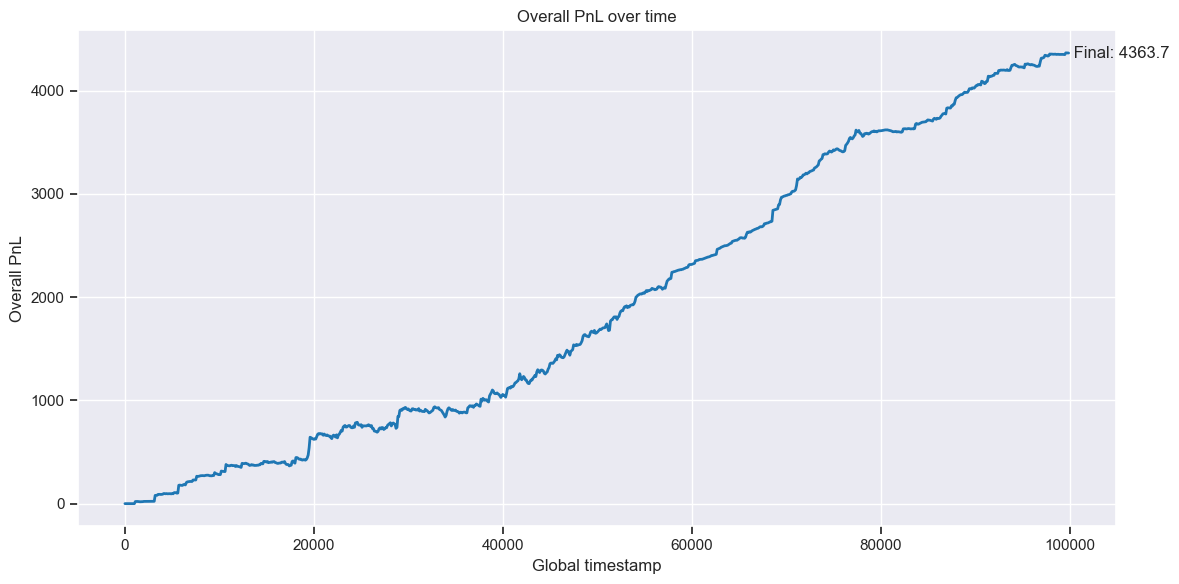

In [44]:
path = "data/version_1.log"
with open(path, "r", encoding="utf-8") as f:
    raw_v1 = json.load(f)

df_performance_v1 = pd.read_csv(StringIO(raw_v1["activitiesLog"]), sep=";")

df_performance_v1["global_timestamp"] = (df_performance_v1["day"] - df_performance_v1["day"].min()) * DAY_LENGTH + df_performance_v1["timestamp"]

overall_pnl = (
    df_performance_v1.groupby("global_timestamp", as_index=False)["profit_and_loss"]
      .sum()
      .sort_values(["global_timestamp"])
)

plt.figure(figsize=(12, 6))
plt.plot(overall_pnl["global_timestamp"], overall_pnl["profit_and_loss"], linewidth=2)

plt.title("Overall PnL over time")
plt.xlabel("Global timestamp")
plt.ylabel("Overall PnL")
plt.grid(True)

final_pnl = overall_pnl["profit_and_loss"].iloc[-1]
plt.text(
    overall_pnl["global_timestamp"].iloc[-1],
    final_pnl,
    f" Final: {final_pnl:.1f}",
    va="center"
)

plt.tight_layout()
plt.show()

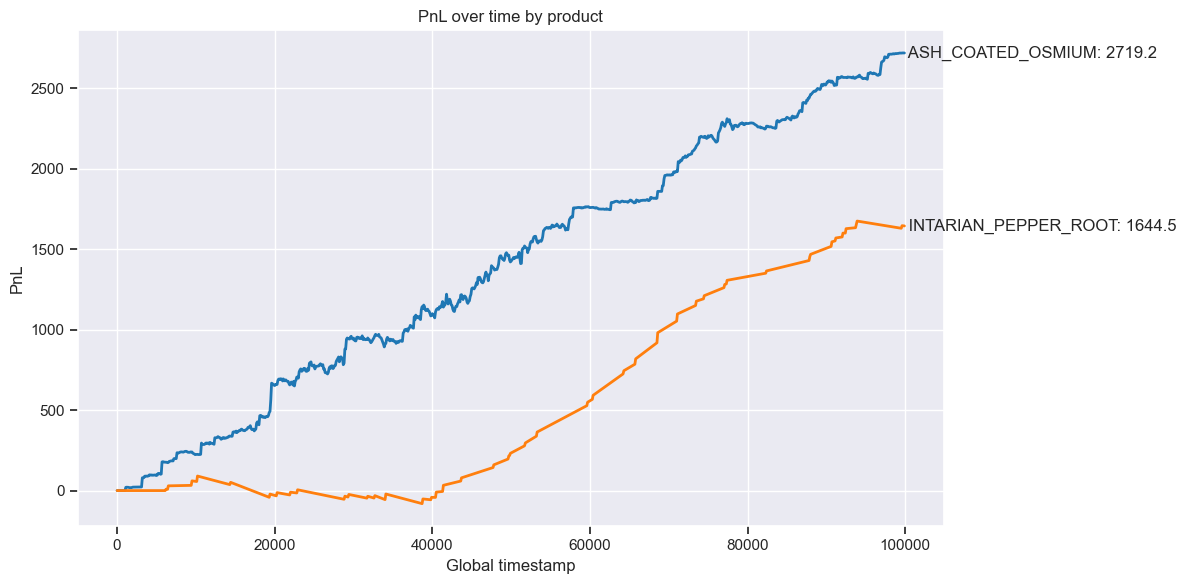

In [45]:
plt.figure(figsize=(12, 6))

for product, g in df_performance_v1.groupby("product"):
    g = g.sort_values("global_timestamp")
    plt.plot(g["global_timestamp"], g["profit_and_loss"], linewidth=2, label=product)
    plt.text(
        g["global_timestamp"].iloc[-1],
        g["profit_and_loss"].iloc[-1],
        f" {product}: {g['profit_and_loss'].iloc[-1]:.1f}",
        va="center"
    )

plt.title("PnL over time by product")
plt.xlabel("Global timestamp")
plt.ylabel("PnL")
plt.grid(True)
plt.tight_layout()
plt.show()

Trading activity:

In [46]:
df_trades_v1 = pd.DataFrame(raw_v1['tradeHistory'])

df_trades_v1['signed_qty']=np.where(df_trades_v1['buyer']=='SUBMISSION', df_trades_v1['quantity'],
                                     np.where(df_trades_v1['seller']=='SUBMISSION', -df_trades_v1['quantity'], 0))
df_trades_v1['cashflow']= -df_trades_v1['signed_qty']*df_trades_v1['price'] 

metrics = {}

for prod,g in df_trades_v1.groupby('symbol'):
    buys = g[g['signed_qty']>0]
    sells = g[g['signed_qty']<0]
    pos = g['signed_qty'].cumsum()
    metrics[prod]={
        'fills': len(g),
        'buy_fills': len(buys),
        'sell_fills': len(sells),
        'buy_qty': buys['signed_qty'].sum(),
        'sell_qty': -sells['signed_qty'].sum(),
        'avg_buy_px': np.average(buys['price'], weights=buys['signed_qty']) if len(buys) else np.nan,
        'avg_sell_px': np.average(sells['price'], weights=-sells['signed_qty']) if len(sells) else np.nan,
        'end_pos': g['signed_qty'].sum(),
        'max_abs_pos': pos.abs().max(),
        'cash_pnl': g['cashflow'].sum(),
    }

pd.DataFrame(metrics).T

,fills,buy_fills,sell_fills,buy_qty,sell_qty,avg_buy_px,avg_sell_px,end_pos,max_abs_pos,cash_pnl
ASH_COATED_OSMIUM,82.0,38.0,35.0,218.0,215.0,9992.935780,10005.446512,3.0,62.0,-27289.0
INTARIAN_PEPPER_ROOT,46.0,24.0,20.0,109.0,114.0,12045.522936,12062.333333,-5.0,37.0,62144.0


Drawdowns:

In [47]:
df_performance_v1_wide = df_performance_v1.pivot(index='timestamp', columns='product', values='profit_and_loss').sort_index()
df_performance_v1_wide['total']=df_performance_v1_wide.sum(axis=1)
dd = df_performance_v1_wide['total'] - df_performance_v1_wide['total'].cummax()

for prod in metrics:

    metrics[prod]['limit_utilization']=metrics[prod]['max_abs_pos']/80

dds={}

for col in ['ASH_COATED_OSMIUM','INTARIAN_PEPPER_ROOT','total']:

    s=df_performance_v1_wide[col]
    dd=s-s.cummax()

    dds[col]={
        'final': s.iloc[-1],
        'max': s.max(),
        'min': s.min(),
        'max_drawdown': dd.min(),
        'time_of_mdd': dd.idxmin(),
    }

pd.DataFrame(dds).T

,final,max,min,max_drawdown,time_of_mdd
ASH_COATED_OSMIUM,2719.15625,2719.406250,0.000000,-107.375,42800.0
INTARIAN_PEPPER_ROOT,1644.50000,1674.796875,-81.109375,-171.500,38700.0
total,4363.65625,4365.138672,0.000000,-99.375,33900.0


Version 1 is already a solid baseline. Final total PnL is **4363.7**, made up of about **2719.2** from `ASH_COATED_OSMIUM` and **1644.5** from `INTARIAN_PEPPER_ROOT`.

The activity table is encouraging for two reasons.

1. **Osmium behaves exactly as intended.**  
It trades actively, captures a healthy spread and finishes close to flat. The realised spread between average buy and average sell is roughly 12.5 ticks, which is fully consistent with anchor based market making around a stable price level.

2. **Pepper is profitable, but underexpressed.**  
Pepper makes money, yet it uses far less of the 80 lot limit than Osmium. Maximum absolute position is only 37 and the strategy records just 46 fills. Given how strong the Pepper fair value signal looked in the research phase, this suggests that the strategy is still too conservative in converting signal into exposure.

Risk is also well controlled. Maximum drawdown in total marked to market PnL is about **-99.4**, which is small relative to the final profit. By product, maximum drawdown is about **-107.4** for Osmium and **-171.5** for Pepper.

The main weakness is therefore not instability. It is incomplete expression of the Pepper edge. The next version should try to increase Pepper participation without damaging the stability already achieved in Osmium.

### 6.4 Version 2

#### 6.4.1 Version 2 trader class

We keep the overall structure and make a targeted Pepper upgrade without changing the Osmium logic.

The central diagnosis is that Pepper is not underperforming because the fair value model is wrong. It is underperforming because the execution layer is still too restrictive. In particular:

- the base estimate is rounded to the nearest 1,000 on every update
- aggressive crossing requires both quote edge and fair premium sign to agree
- passive quotes remain one tick away from reservation even when the signal is strong
- position management is symmetric even though Pepper fair value rises deterministically through the day

The most problematic condition is `if buy_edge >= 1 and fair_premium >= 0 and buy_room > 0:`. Since `fair_premium = fair - mid`, this can block an attractive buy at the ask simply because the mid sits slightly above fair due to book shape. The same logic can also block valid sells. That makes the strategy unnecessarily selective exactly where Pepper should be more expressive.

Version 2 therefore makes four targeted changes.

1. **A smoother Pepper base estimate.**  
Instead of repeatedly snapping the smoothed base back to the nearest 1,000, we let it update continuously after the initial estimate. That should preserve the fair value structure while avoiding unnecessary discretisation.

2. **Use quote edge directly for aggressive taking.**  
A quote can be attractive in its own right even if the current mid is slightly on the other side of fair. We therefore condition aggressive buys and sells on quote edge rather than on quote edge plus fair premium sign.

3. **Larger aggressive size when the edge is stronger.**  
The aggressive size cap is tiered rather than fixed, so strong deviations can translate into more inventory.

4. **Slightly softer Pepper inventory penalty and more responsive passive quoting.**  
This should make the strategy more willing to express the signal when fair value deviation is meaningful.

In [ ]:
from datamodel import Order, OrderDepth, TradingState
from typing import Dict, List
import json
import math


class Trader:
    POSITION_LIMITS: Dict[str, int] = {
        'ASH_COATED_OSMIUM': 80,
        'INTARIAN_PEPPER_ROOT': 80,
    }

    def load_state(self, trader_data: str) -> Dict:
        if trader_data:
            try:
                return json.loads(trader_data)
            except Exception:
                return {}
        return {}

    def dump_state(self, state: Dict) -> str:
        return json.dumps(state)

    def best_bid_ask(self, order_depth: OrderDepth):
        best_bid = max(order_depth.buy_orders) if order_depth.buy_orders else None
        best_ask = min(order_depth.sell_orders) if order_depth.sell_orders else None

        bid_vol = order_depth.buy_orders.get(best_bid, 0) if best_bid is not None else 0
        ask_vol = -order_depth.sell_orders.get(best_ask, 0) if best_ask is not None else 0

        return best_bid, bid_vol, best_ask, ask_vol

    def place_buy(self, orders: List[Order], product: str, price: int, size: int):
        if size > 0:
            orders.append(Order(product, int(price), int(size)))

    def place_sell(self, orders: List[Order], product: str, price: int, size: int):
        if size > 0:
            orders.append(Order(product, int(price), int(-size)))

    def l1_imbalance(self, bid_vol: int, ask_vol: int) -> float:
        total = bid_vol + ask_vol
        if total <= 0:
            return 0.0
        return (bid_vol - ask_vol) / total

    def update_pepper_base(self, memory: Dict, timestamp: int, mid: float) -> float:
        observed_base = mid - timestamp / 1000.0
        previous_base = memory.get('pepper_base')

        if previous_base is None:
            base = round(observed_base / 1000.0) * 1000.0
        else:
            base = 0.90 * float(previous_base) + 0.10 * observed_base

        memory['pepper_base'] = base
        return base

    def trade_osmium(self, product: str, order_depth: OrderDepth, position: int, timestamp: int) -> List[Order]:
        orders: List[Order] = []
        limit = self.POSITION_LIMITS[product]

        best_bid, bid_vol, best_ask, ask_vol = self.best_bid_ask(order_depth)
        if best_bid is None or best_ask is None:
            return orders

        fair = 10000.0
        imbalance = self.l1_imbalance(bid_vol, ask_vol)

        inventory_penalty = 0.10
        imbalance_lean = 2.5 * imbalance
        reservation = fair + imbalance_lean - inventory_penalty * position

        buy_room = limit - position
        sell_room = limit + position

        aggressive_buy_edge = fair - best_ask
        aggressive_sell_edge = best_bid - fair

        if aggressive_buy_edge >= 2 and imbalance >= -0.15 and buy_room > 0:
            size = min(buy_room, ask_vol, 12)
            self.place_buy(orders, product, best_ask, size)
            buy_room -= size

        if aggressive_sell_edge >= 2 and imbalance <= 0.15 and sell_room > 0:
            size = min(sell_room, bid_vol, 12)
            self.place_sell(orders, product, best_bid, size)
            sell_room -= size

        bid_quote = min(best_bid + 1, math.floor(reservation - 1))
        ask_quote = max(best_ask - 1, math.ceil(reservation + 1))

        if bid_quote < ask_quote:
            base_passive = 10
            buy_size = min(buy_room, max(0, base_passive - max(position, 0) // 10))
            sell_size = min(sell_room, max(0, base_passive - max(-position, 0) // 10))

            if buy_size > 0:
                self.place_buy(orders, product, bid_quote, buy_size)
            if sell_size > 0:
                self.place_sell(orders, product, ask_quote, sell_size)

        if timestamp >= 950000:
            if position > 0 and sell_room > 0:
                size = min(position, sell_room, max(1, bid_vol))
                self.place_sell(orders, product, best_bid, size)
            elif position < 0 and buy_room > 0:
                size = min(-position, buy_room, max(1, ask_vol))
                self.place_buy(orders, product, best_ask, size)

        return orders

    def trade_pepper(self, product: str, order_depth: OrderDepth, position: int, timestamp: int, memory: Dict) -> List[Order]:
        orders: List[Order] = []
        limit = self.POSITION_LIMITS[product]

        best_bid, bid_vol, best_ask, ask_vol = self.best_bid_ask(order_depth)
        if best_bid is None or best_ask is None:
            return orders

        mid = 0.5 * (best_bid + best_ask)
        imbalance = self.l1_imbalance(bid_vol, ask_vol)

        base = self.update_pepper_base(memory, timestamp, mid)
        fair = base + timestamp / 1000.0

        inventory_penalty = 0.10
        imbalance_lean = 1.5 * imbalance
        reservation = fair + imbalance_lean - inventory_penalty * position

        buy_room = limit - position
        sell_room = limit + position

        fair_premium = fair - mid
        buy_edge = fair - best_ask
        sell_edge = best_bid - fair

        if buy_edge >= 1 and imbalance >= -0.35 and buy_room > 0:
            max_take = 16
            if buy_edge >= 2:
                max_take = 22
            if buy_edge >= 3:
                max_take = 28
            size = min(buy_room, ask_vol, max_take)
            self.place_buy(orders, product, best_ask, size)
            buy_room -= size

        if sell_edge >= 1 and imbalance <= 0.35 and sell_room > 0:
            max_take = 16
            if sell_edge >= 2:
                max_take = 22
            if sell_edge >= 3:
                max_take = 28
            size = min(sell_room, bid_vol, max_take)
            self.place_sell(orders, product, best_bid, size)
            sell_room -= size

        bid_quote = min(best_bid + 1, math.floor(reservation - 1))
        ask_quote = max(best_ask - 1, math.ceil(reservation + 1))

        if bid_quote < ask_quote:
            base_passive = 12
            if abs(fair_premium) >= 1:
                base_passive = 16

            buy_size = min(buy_room, max(0, base_passive - max(position, 0) // 8))
            sell_size = min(sell_room, max(0, base_passive - max(-position, 0) // 8))

            if buy_size > 0:
                self.place_buy(orders, product, bid_quote, buy_size)
            if sell_size > 0:
                self.place_sell(orders, product, ask_quote, sell_size)

        if timestamp >= 940000:
            if position > 0 and sell_room > 0:
                size = min(position, sell_room, max(1, bid_vol))
                self.place_sell(orders, product, best_bid, size)
            elif position < 0 and buy_room > 0:
                size = min(-position, buy_room, max(1, ask_vol))
                self.place_buy(orders, product, best_ask, size)

        return orders

    def run(self, state: TradingState):
        result: Dict[str, List[Order]] = {}
        memory = self.load_state(state.traderData)

        for product, order_depth in state.order_depths.items():
            position = state.position.get(product, 0)

            if product == 'ASH_COATED_OSMIUM':
                result[product] = self.trade_osmium(
                    product=product,
                    order_depth=order_depth,
                    position=position,
                    timestamp=state.timestamp,
                )

            elif product == 'INTARIAN_PEPPER_ROOT':
                result[product] = self.trade_pepper(
                    product=product,
                    order_depth=order_depth,
                    position=position,
                    timestamp=state.timestamp,
                    memory=memory,
                )

            else:
                result[product] = []

        trader_data = self.dump_state(memory)
        conversions = 0
        return result, conversions, trader_data

#### 6.4.2 Version 2 Performance

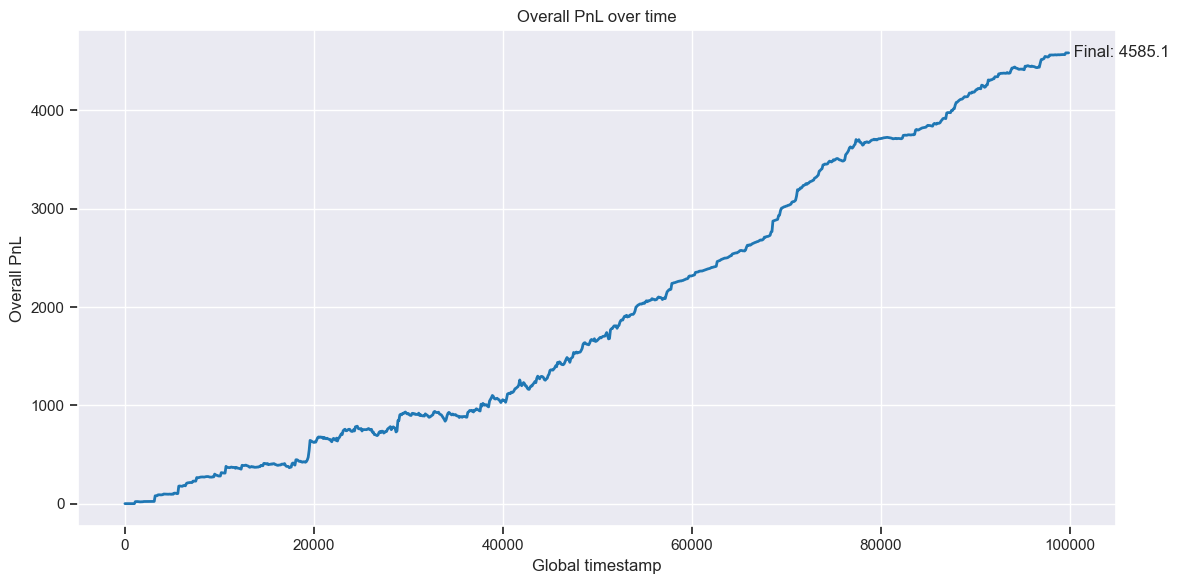

In [48]:
path = "data/version_2.log"
with open(path, "r", encoding="utf-8") as f:
    raw_v2 = json.load(f)

df_performance_v2 = pd.read_csv(StringIO(raw_v2["activitiesLog"]), sep=";")

df_performance_v2["global_timestamp"] = (df_performance_v2["day"] - df_performance_v2["day"].min()) * DAY_LENGTH + df_performance_v2["timestamp"]

overall_pnl = (
    df_performance_v2.groupby("global_timestamp", as_index=False)["profit_and_loss"]
      .sum()
      .sort_values(["global_timestamp"])
)

plt.figure(figsize=(12, 6))
plt.plot(overall_pnl["global_timestamp"], overall_pnl["profit_and_loss"], linewidth=2)

plt.title("Overall PnL over time")
plt.xlabel("Global timestamp")
plt.ylabel("Overall PnL")
plt.grid(True)

final_pnl = overall_pnl["profit_and_loss"].iloc[-1]
plt.text(
    overall_pnl["global_timestamp"].iloc[-1],
    final_pnl,
    f" Final: {final_pnl:.1f}",
    va="center"
)

plt.tight_layout()
plt.show()

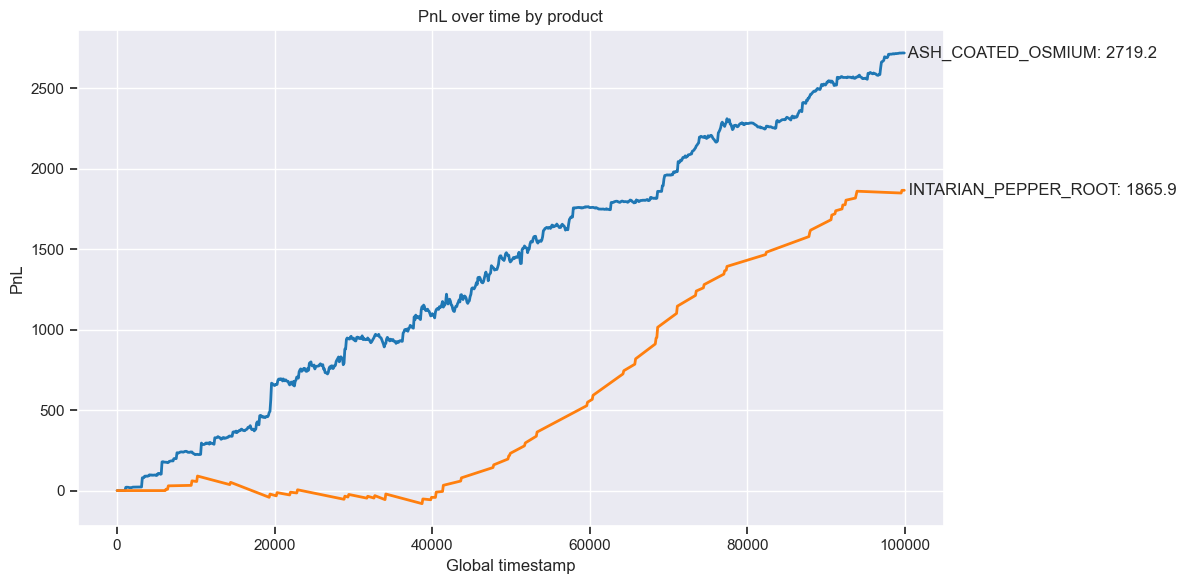

In [49]:
plt.figure(figsize=(12, 6))

for product, g in df_performance_v2.groupby("product"):
    g = g.sort_values("global_timestamp")
    plt.plot(g["global_timestamp"], g["profit_and_loss"], linewidth=2, label=product)
    plt.text(
        g["global_timestamp"].iloc[-1],
        g["profit_and_loss"].iloc[-1],
        f" {product}: {g['profit_and_loss'].iloc[-1]:.1f}",
        va="center"
    )

plt.title("PnL over time by product")
plt.xlabel("Global timestamp")
plt.ylabel("PnL")
plt.grid(True)
plt.tight_layout()
plt.show()

Trading activity:

In [50]:
df_trades_v2 = pd.DataFrame(raw_v2['tradeHistory'])

df_trades_v2['signed_qty']=np.where(df_trades_v2['buyer']=='SUBMISSION', df_trades_v2['quantity'],
                                     np.where(df_trades_v2['seller']=='SUBMISSION', -df_trades_v2['quantity'], 0))
df_trades_v2['cashflow']= -df_trades_v2['signed_qty']*df_trades_v2['price'] 

metrics = {}

for prod,g in df_trades_v2.groupby('symbol'):
    buys = g[g['signed_qty']>0]
    sells = g[g['signed_qty']<0]
    pos = g['signed_qty'].cumsum()
    metrics[prod]={
        'fills': len(g),
        'buy_fills': len(buys),
        'sell_fills': len(sells),
        'buy_qty': buys['signed_qty'].sum(),
        'sell_qty': -sells['signed_qty'].sum(),
        'avg_buy_px': np.average(buys['price'], weights=buys['signed_qty']) if len(buys) else np.nan,
        'avg_sell_px': np.average(sells['price'], weights=-sells['signed_qty']) if len(sells) else np.nan,
        'end_pos': g['signed_qty'].sum(),
        'max_abs_pos': pos.abs().max(),
        'cash_pnl': g['cashflow'].sum(),
    }

pd.DataFrame(metrics).T

,fills,buy_fills,sell_fills,buy_qty,sell_qty,avg_buy_px,avg_sell_px,end_pos,max_abs_pos,cash_pnl
ASH_COATED_OSMIUM,82.0,38.0,35.0,218.0,215.0,9992.935780,10005.446512,3.0,62.0,-27289.0
INTARIAN_PEPPER_ROOT,46.0,25.0,20.0,115.0,114.0,12046.434783,12062.333333,1.0,43.0,-10234.0


Drawdowns:

In [51]:
df_performance_v2_wide = df_performance_v2.pivot(index='timestamp', columns='product', values='profit_and_loss').sort_index()
df_performance_v2_wide['total']=df_performance_v2_wide.sum(axis=1)
dd = df_performance_v2_wide['total'] - df_performance_v2_wide['total'].cummax()

for prod in metrics:

    metrics[prod]['limit_utilization']=metrics[prod]['max_abs_pos']/80

dds={}

for col in ['ASH_COATED_OSMIUM','INTARIAN_PEPPER_ROOT','total']:

    s=df_performance_v2_wide[col]
    dd=s-s.cummax()

    dds[col]={
        'final': s.iloc[-1],
        'max': s.max(),
        'min': s.min(),
        'max_drawdown': dd.min(),
        'time_of_mdd': dd.idxmin(),
    }

pd.DataFrame(dds).T

,final,max,min,max_drawdown,time_of_mdd
ASH_COATED_OSMIUM,2719.156250,2719.406250,0.000000,-107.375,42800.0
INTARIAN_PEPPER_ROOT,1865.900391,1865.900391,-81.109375,-171.500,38700.0
total,4585.056641,4585.155273,0.000000,-99.375,33900.0


Version 2 improves the strategy, lifting total PnL to about **4585.1**. Osmium is unchanged at about **2719.2**, while Pepper rises to about **1865.9**.

The improvement confirms the diagnosis that Version 1 was too conservative. However, the PnL path also reveals the remaining weakness very clearly. Pepper stays near flat or negative for roughly the first 40,000 timestamps before the curve accelerates upward. That pattern is exactly what we would expect if early fills leave the strategy net short in a product whose fair value rises deterministically through the day.

So Version 2 fixes part of the expression problem, but not the inventory problem. The next step is to make Pepper inventory management asymmetric so that being short is treated as more dangerous than being long.

### 6.5 Version 3

#### 6.5.1 Version 3 trader class

Version 3 responds directly to the main weakness of Version 2. The changes are designed to make short inventory in Pepper less persistent and less comfortable:

- shorts are penalised more heavily than longs
- buying back shorts becomes easier than initiating fresh sells
- passive quoting leans more to the buy side when Pepper is short
- aggressive sells require slightly more edge than aggressive buys

The economic logic is simple. In an upward drifting product, a short position fights both the market and the fair value process. Inventory control should therefore reflect the product regime rather than remain perfectly symmetric.

In [ ]:
from datamodel import Order, OrderDepth, TradingState
from typing import Dict, List
import json
import math


class Trader:
    POSITION_LIMITS: Dict[str, int] = {
        'ASH_COATED_OSMIUM': 80,
        'INTARIAN_PEPPER_ROOT': 80,
    }

    def load_state(self, trader_data: str) -> Dict:
        if trader_data:
            try:
                return json.loads(trader_data)
            except Exception:
                return {}
        return {}

    def dump_state(self, state: Dict) -> str:
        return json.dumps(state)

    def best_bid_ask(self, order_depth: OrderDepth):
        best_bid = max(order_depth.buy_orders) if order_depth.buy_orders else None
        best_ask = min(order_depth.sell_orders) if order_depth.sell_orders else None

        bid_vol = order_depth.buy_orders.get(best_bid, 0) if best_bid is not None else 0
        ask_vol = -order_depth.sell_orders.get(best_ask, 0) if best_ask is not None else 0

        return best_bid, bid_vol, best_ask, ask_vol

    def place_buy(self, orders: List[Order], product: str, price: int, size: int):
        if size > 0:
            orders.append(Order(product, int(price), int(size)))

    def place_sell(self, orders: List[Order], product: str, price: int, size: int):
        if size > 0:
            orders.append(Order(product, int(price), int(-size)))

    def l1_imbalance(self, bid_vol: int, ask_vol: int) -> float:
        total = bid_vol + ask_vol
        if total <= 0:
            return 0.0
        return (bid_vol - ask_vol) / total

    def update_pepper_base(self, memory: Dict, timestamp: int, mid: float) -> float:
        observed_base = mid - timestamp / 1000.0
        previous_base = memory.get('pepper_base')

        if previous_base is None:
            base = round(observed_base / 1000.0) * 1000.0
        else:
            base = 0.90 * float(previous_base) + 0.10 * observed_base

        memory['pepper_base'] = base
        return base

    def trade_osmium(self, product: str, order_depth: OrderDepth, position: int, timestamp: int) -> List[Order]:
        orders: List[Order] = []
        limit = self.POSITION_LIMITS[product]

        best_bid, bid_vol, best_ask, ask_vol = self.best_bid_ask(order_depth)
        if best_bid is None or best_ask is None:
            return orders

        fair = 10000.0
        imbalance = self.l1_imbalance(bid_vol, ask_vol)

        inventory_penalty = 0.10
        imbalance_lean = 2.5 * imbalance
        reservation = fair + imbalance_lean - inventory_penalty * position

        buy_room = limit - position
        sell_room = limit + position

        aggressive_buy_edge = fair - best_ask
        aggressive_sell_edge = best_bid - fair

        if aggressive_buy_edge >= 2 and imbalance >= -0.15 and buy_room > 0:
            size = min(buy_room, ask_vol, 12)
            self.place_buy(orders, product, best_ask, size)
            buy_room -= size

        if aggressive_sell_edge >= 2 and imbalance <= 0.15 and sell_room > 0:
            size = min(sell_room, bid_vol, 12)
            self.place_sell(orders, product, best_bid, size)
            sell_room -= size

        bid_quote = min(best_bid + 1, math.floor(reservation - 1))
        ask_quote = max(best_ask - 1, math.ceil(reservation + 1))

        if bid_quote < ask_quote:
            base_passive = 10
            buy_size = min(buy_room, max(0, base_passive - max(position, 0) // 10))
            sell_size = min(sell_room, max(0, base_passive - max(-position, 0) // 10))

            if buy_size > 0:
                self.place_buy(orders, product, bid_quote, buy_size)
            if sell_size > 0:
                self.place_sell(orders, product, ask_quote, sell_size)

        if timestamp >= 950000:
            if position > 0 and sell_room > 0:
                size = min(position, sell_room, max(1, bid_vol))
                self.place_sell(orders, product, best_bid, size)
            elif position < 0 and buy_room > 0:
                size = min(-position, buy_room, max(1, ask_vol))
                self.place_buy(orders, product, best_ask, size)

        return orders

    def trade_pepper(self, product: str, order_depth: OrderDepth, position: int, timestamp: int, memory: Dict) -> List[Order]:
        orders: List[Order] = []
        limit = self.POSITION_LIMITS[product]

        best_bid, bid_vol, best_ask, ask_vol = self.best_bid_ask(order_depth)
        if best_bid is None or best_ask is None:
            return orders

        mid = 0.5 * (best_bid + best_ask)
        imbalance = self.l1_imbalance(bid_vol, ask_vol)

        base = self.update_pepper_base(memory, timestamp, mid)
        fair = base + timestamp / 1000.0

        # Asymmetric inventory treatment:
        # being short is more dangerous than being long in an upward-drifting product
        if position < 0:
            inventory_penalty = 0.16
        else:
            inventory_penalty = 0.08

        imbalance_lean = 1.2 * imbalance
        reservation = fair + imbalance_lean - inventory_penalty * position

        buy_room = limit - position
        sell_room = limit + position

        fair_premium = fair - mid
        buy_edge = fair - best_ask
        sell_edge = best_bid - fair

        # Short-cover / long-bias logic:
        # easier to buy than to sell, especially when already short
        buy_threshold = 0.5 if position < 0 else 1.0
        sell_threshold = 1.5 if position < 0 else 1.0

        if buy_edge >= buy_threshold and imbalance >= -0.45 and buy_room > 0:
            max_take = 16
            if buy_edge >= 1.5:
                max_take = 22
            if buy_edge >= 2.5:
                max_take = 28
            if position < 0:
                max_take += 6

            size = min(buy_room, ask_vol, max_take)
            self.place_buy(orders, product, best_ask, size)
            buy_room -= size

        if sell_edge >= sell_threshold and imbalance <= 0.25 and sell_room > 0:
            max_take = 14
            if sell_edge >= 2.0:
                max_take = 20
            if sell_edge >= 3.0:
                max_take = 26
            if position > 30:
                max_take += 4

            size = min(sell_room, bid_vol, max_take)
            self.place_sell(orders, product, best_bid, size)
            sell_room -= size

        # Passive quoting:
        # if short, lean more to the buy side and be less eager to post sells
        bid_quote = min(best_bid + 1, math.floor(reservation - 1))
        ask_quote = max(best_ask - 1, math.ceil(reservation + 1))

        if bid_quote < ask_quote:
            base_passive = 12
            if abs(fair_premium) >= 1:
                base_passive = 16

            if position < 0:
                buy_size = min(buy_room, base_passive + min(10, -position // 4))
                sell_size = min(sell_room, max(0, base_passive - 6 - min(8, -position // 6)))
            elif position > 0:
                buy_size = min(buy_room, max(0, base_passive - min(8, position // 6)))
                sell_size = min(sell_room, base_passive + min(6, position // 8))
            else:
                buy_size = min(buy_room, base_passive)
                sell_size = min(sell_room, base_passive)

            if buy_size > 0:
                self.place_buy(orders, product, bid_quote, buy_size)
            if sell_size > 0:
                self.place_sell(orders, product, ask_quote, sell_size)

        # End-of-day flattening
        if timestamp >= 940000:
            if position > 0 and sell_room > 0:
                size = min(position, sell_room, max(1, bid_vol))
                self.place_sell(orders, product, best_bid, size)
            elif position < 0 and buy_room > 0:
                size = min(-position, buy_room, max(1, ask_vol))
                self.place_buy(orders, product, best_ask, size)

        return orders

    def run(self, state: TradingState):
        result: Dict[str, List[Order]] = {}
        memory = self.load_state(state.traderData)

        for product, order_depth in state.order_depths.items():
            position = state.position.get(product, 0)

            if product == 'ASH_COATED_OSMIUM':
                result[product] = self.trade_osmium(
                    product=product,
                    order_depth=order_depth,
                    position=position,
                    timestamp=state.timestamp,
                )

            elif product == 'INTARIAN_PEPPER_ROOT':
                result[product] = self.trade_pepper(
                    product=product,
                    order_depth=order_depth,
                    position=position,
                    timestamp=state.timestamp,
                    memory=memory,
                )

            else:
                result[product] = []

        trader_data = self.dump_state(memory)
        conversions = 0
        return result, conversions, trader_data

#### 6.5.2. Version 3 Performance

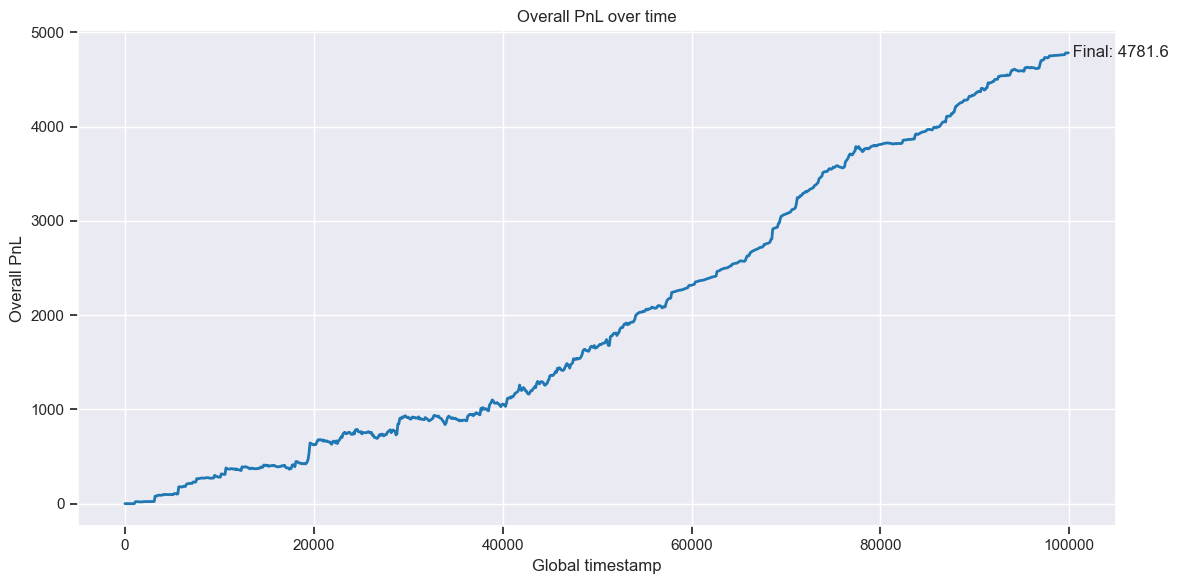

In [52]:
path = "data/version_3.log"
with open(path, "r", encoding="utf-8") as f:
    raw_v3 = json.load(f)

df_performance_v3 = pd.read_csv(StringIO(raw_v3["activitiesLog"]), sep=";")

df_performance_v3["global_timestamp"] = (df_performance_v3["day"] - df_performance_v3["day"].min()) * DAY_LENGTH + df_performance_v3["timestamp"]

overall_pnl = (
    df_performance_v3.groupby("global_timestamp", as_index=False)["profit_and_loss"]
      .sum()
      .sort_values(["global_timestamp"])
)

plt.figure(figsize=(12, 6))
plt.plot(overall_pnl["global_timestamp"], overall_pnl["profit_and_loss"], linewidth=2)

plt.title("Overall PnL over time")
plt.xlabel("Global timestamp")
plt.ylabel("Overall PnL")
plt.grid(True)

final_pnl = overall_pnl["profit_and_loss"].iloc[-1]
plt.text(
    overall_pnl["global_timestamp"].iloc[-1],
    final_pnl,
    f" Final: {final_pnl:.1f}",
    va="center"
)

plt.tight_layout()
plt.show()

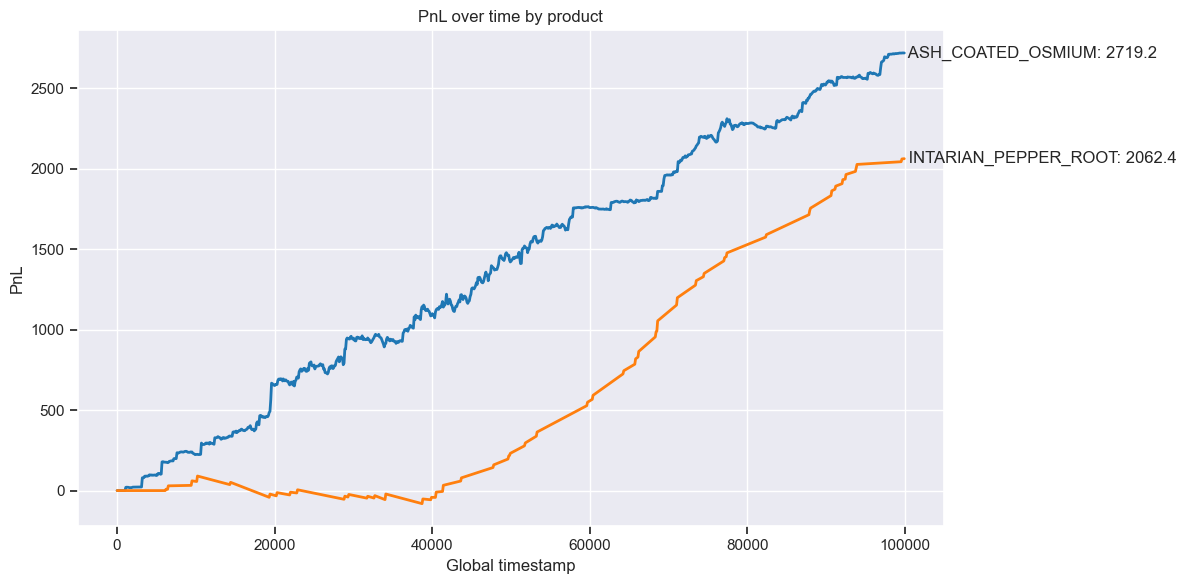

In [53]:
plt.figure(figsize=(12, 6))

for product, g in df_performance_v3.groupby("product"):
    g = g.sort_values("global_timestamp")
    plt.plot(g["global_timestamp"], g["profit_and_loss"], linewidth=2, label=product)
    plt.text(
        g["global_timestamp"].iloc[-1],
        g["profit_and_loss"].iloc[-1],
        f" {product}: {g['profit_and_loss'].iloc[-1]:.1f}",
        va="center"
    )

plt.title("PnL over time by product")
plt.xlabel("Global timestamp")
plt.ylabel("PnL")
plt.grid(True)
plt.tight_layout()
plt.show()

Trading activity:

In [54]:
df_trades_v3 = pd.DataFrame(raw_v3['tradeHistory'])

df_trades_v3['signed_qty']=np.where(df_trades_v3['buyer']=='SUBMISSION', df_trades_v3['quantity'],
                                     np.where(df_trades_v3['seller']=='SUBMISSION', -df_trades_v3['quantity'], 0))
df_trades_v3['cashflow']= -df_trades_v3['signed_qty']*df_trades_v3['price'] 

metrics = {}

for prod,g in df_trades_v3.groupby('symbol'):
    buys = g[g['signed_qty']>0]
    sells = g[g['signed_qty']<0]
    pos = g['signed_qty'].cumsum()
    metrics[prod]={
        'fills': len(g),
        'buy_fills': len(buys),
        'sell_fills': len(sells),
        'buy_qty': buys['signed_qty'].sum(),
        'sell_qty': -sells['signed_qty'].sum(),
        'avg_buy_px': np.average(buys['price'], weights=buys['signed_qty']) if len(buys) else np.nan,
        'avg_sell_px': np.average(sells['price'], weights=-sells['signed_qty']) if len(sells) else np.nan,
        'end_pos': g['signed_qty'].sum(),
        'max_abs_pos': pos.abs().max(),
        'cash_pnl': g['cashflow'].sum(),
    }

pd.DataFrame(metrics).T

,fills,buy_fills,sell_fills,buy_qty,sell_qty,avg_buy_px,avg_sell_px,end_pos,max_abs_pos,cash_pnl
ASH_COATED_OSMIUM,82.0,38.0,35.0,218.0,215.0,9992.93578,10005.446512,3.0,62.0,-27289.0
INTARIAN_PEPPER_ROOT,46.0,26.0,20.0,120.0,114.0,12047.02500,12062.333333,6.0,48.0,-70537.0


Drawdowns:

In [55]:
df_performance_v3_wide = df_performance_v3.pivot(index='timestamp', columns='product', values='profit_and_loss').sort_index()
df_performance_v3_wide['total']=df_performance_v3_wide.sum(axis=1)
dd = df_performance_v3_wide['total'] - df_performance_v3_wide['total'].cummax()

for prod in metrics:

    metrics[prod]['limit_utilization']=metrics[prod]['max_abs_pos']/80

dds={}

for col in ['ASH_COATED_OSMIUM','INTARIAN_PEPPER_ROOT','total']:

    s=df_performance_v2_wide[col]
    dd=s-s.cummax()

    dds[col]={
        'final': s.iloc[-1],
        'max': s.max(),
        'min': s.min(),
        'max_drawdown': dd.min(),
        'time_of_mdd': dd.idxmin(),
    }

pd.DataFrame(dds).T

,final,max,min,max_drawdown,time_of_mdd
ASH_COATED_OSMIUM,2719.156250,2719.406250,0.000000,-107.375,42800.0
INTARIAN_PEPPER_ROOT,1865.900391,1865.900391,-81.109375,-171.500,38700.0
total,4585.056641,4585.155273,0.000000,-99.375,33900.0


Version 3 performs better again. Final Pepper PnL rises to about **2062.4**, giving a total of roughly **4781.6**. The curve also looks healthier than in Version 2: Pepper still has a soft opening phase, but the early drag is less pronounced and the upward progression becomes more consistent.

That said, the underlying idea can be pushed one step further. If Pepper fair value rises almost deterministically within each day, then a mild long bias is structurally safer than a mild short bias. Version 4 therefore tests a controlled long leaning specification for Pepper. The aim is not to abandon fair value trading, but to align the inventory target more closely with the market regime.

### 6.6 Version 4

#### 6.6.1 Version 4 trader class

In [ ]:
from datamodel import Order, OrderDepth, TradingState
from typing import Dict, List
import json
import math


class Trader:
    POSITION_LIMITS: Dict[str, int] = {
        'ASH_COATED_OSMIUM': 80,
        'INTARIAN_PEPPER_ROOT': 80,
    }

    def load_state(self, trader_data: str) -> Dict:
        if trader_data:
            try:
                return json.loads(trader_data)
            except Exception:
                return {}
        return {}

    def dump_state(self, state: Dict) -> str:
        return json.dumps(state)

    def best_bid_ask(self, order_depth: OrderDepth):
        best_bid = max(order_depth.buy_orders) if order_depth.buy_orders else None
        best_ask = min(order_depth.sell_orders) if order_depth.sell_orders else None

        bid_vol = order_depth.buy_orders.get(best_bid, 0) if best_bid is not None else 0
        ask_vol = -order_depth.sell_orders.get(best_ask, 0) if best_ask is not None else 0

        return best_bid, bid_vol, best_ask, ask_vol

    def place_buy(self, orders: List[Order], product: str, price: int, size: int):
        if size > 0:
            orders.append(Order(product, int(price), int(size)))

    def place_sell(self, orders: List[Order], product: str, price: int, size: int):
        if size > 0:
            orders.append(Order(product, int(price), int(-size)))

    def l1_imbalance(self, bid_vol: int, ask_vol: int) -> float:
        total = bid_vol + ask_vol
        if total <= 0:
            return 0.0
        return (bid_vol - ask_vol) / total

    def update_pepper_base(self, memory: Dict, timestamp: int, mid: float) -> float:
        observed_base = mid - timestamp / 1000.0
        previous_base = memory.get('pepper_base')

        if previous_base is None:
            base = round(observed_base / 1000.0) * 1000.0
        else:
            base = 0.90 * float(previous_base) + 0.10 * observed_base

        memory['pepper_base'] = base
        return base

    def pepper_target_position(self, timestamp: int) -> int:
        # Mild structural long bias that fades into the close.
        # Early day target is higher, then decays gradually.
        if timestamp < 200000:
            return 24
        if timestamp < 400000:
            return 20
        if timestamp < 600000:
            return 16
        if timestamp < 800000:
            return 10
        if timestamp < 920000:
            return 4
        return 0

    def trade_osmium(self, product: str, order_depth: OrderDepth, position: int, timestamp: int) -> List[Order]:
        orders: List[Order] = []
        limit = self.POSITION_LIMITS[product]

        best_bid, bid_vol, best_ask, ask_vol = self.best_bid_ask(order_depth)
        if best_bid is None or best_ask is None:
            return orders

        fair = 10000.0
        imbalance = self.l1_imbalance(bid_vol, ask_vol)

        inventory_penalty = 0.10
        imbalance_lean = 2.5 * imbalance
        reservation = fair + imbalance_lean - inventory_penalty * position

        buy_room = limit - position
        sell_room = limit + position

        aggressive_buy_edge = fair - best_ask
        aggressive_sell_edge = best_bid - fair

        if aggressive_buy_edge >= 2 and imbalance >= -0.15 and buy_room > 0:
            size = min(buy_room, ask_vol, 12)
            self.place_buy(orders, product, best_ask, size)
            buy_room -= size

        if aggressive_sell_edge >= 2 and imbalance <= 0.15 and sell_room > 0:
            size = min(sell_room, bid_vol, 12)
            self.place_sell(orders, product, best_bid, size)
            sell_room -= size

        bid_quote = min(best_bid + 1, math.floor(reservation - 1))
        ask_quote = max(best_ask - 1, math.ceil(reservation + 1))

        if bid_quote < ask_quote:
            base_passive = 10
            buy_size = min(buy_room, max(0, base_passive - max(position, 0) // 10))
            sell_size = min(sell_room, max(0, base_passive - max(-position, 0) // 10))

            if buy_size > 0:
                self.place_buy(orders, product, bid_quote, buy_size)
            if sell_size > 0:
                self.place_sell(orders, product, ask_quote, sell_size)

        if timestamp >= 950000:
            if position > 0 and sell_room > 0:
                size = min(position, sell_room, max(1, bid_vol))
                self.place_sell(orders, product, best_bid, size)
            elif position < 0 and buy_room > 0:
                size = min(-position, buy_room, max(1, ask_vol))
                self.place_buy(orders, product, best_ask, size)

        return orders

    def trade_pepper(self, product: str, order_depth: OrderDepth, position: int, timestamp: int, memory: Dict) -> List[Order]:
        orders: List[Order] = []
        limit = self.POSITION_LIMITS[product]

        best_bid, bid_vol, best_ask, ask_vol = self.best_bid_ask(order_depth)
        if best_bid is None or best_ask is None:
            return orders

        mid = 0.5 * (best_bid + best_ask)
        imbalance = self.l1_imbalance(bid_vol, ask_vol)

        base = self.update_pepper_base(memory, timestamp, mid)
        fair = base + timestamp / 1000.0

        target_pos = self.pepper_target_position(timestamp)
        target_gap = target_pos - position

        # Mild upward drift bias:
        # actual inventory still matters, but being below target should pull reservation up.
        inventory_penalty = 0.09
        target_penalty = 0.07
        imbalance_lean = 1.1 * imbalance

        reservation = (
            fair
            + imbalance_lean
            - inventory_penalty * position
            + target_penalty * target_gap
        )

        buy_room = limit - position
        sell_room = limit + position

        fair_premium = fair - mid
        buy_edge = fair - best_ask
        sell_edge = best_bid - fair

        under_target = position < target_pos
        far_under_target = position < target_pos - 10
        over_target = position > target_pos + 8

        # Easier to buy than sell, especially when below target.
        buy_threshold = 0.5 if under_target else 1.0
        sell_threshold = 1.75 if under_target else 1.0

        # Aggressive buys
        if buy_edge >= buy_threshold and imbalance >= -0.50 and buy_room > 0:
            max_take = 16
            if buy_edge >= 1.5:
                max_take = 22
            if buy_edge >= 2.5:
                max_take = 28
            if far_under_target:
                max_take += 8

            size = min(buy_room, ask_vol, max_take)
            self.place_buy(orders, product, best_ask, size)
            buy_room -= size

        # Opportunistic target-building buy even if strict edge is small
        if under_target and fair_premium >= 0.5 and buy_room > 0 and best_ask <= math.floor(reservation):
            size = min(buy_room, ask_vol, 8 if not far_under_target else 12)
            self.place_buy(orders, product, best_ask, size)
            buy_room -= size

        # Aggressive sells
        if sell_edge >= sell_threshold and imbalance <= 0.20 and sell_room > 0:
            max_take = 12
            if sell_edge >= 2.0:
                max_take = 18
            if sell_edge >= 3.0:
                max_take = 24
            if over_target:
                max_take += 6

            size = min(sell_room, bid_vol, max_take)
            self.place_sell(orders, product, best_bid, size)
            sell_room -= size

        # Passive quoting with target-long bias
        bid_quote = min(best_bid + 1, math.floor(reservation - 1))
        ask_quote = max(best_ask - 1, math.ceil(reservation + 1))

        if bid_quote < ask_quote:
            base_passive = 12
            if abs(fair_premium) >= 1:
                base_passive = 16

            if under_target:
                buy_size = min(buy_room, base_passive + min(12, max(0, target_gap) // 2 + 4))
                sell_size = min(sell_room, max(0, base_passive - 8))
            elif over_target:
                buy_size = min(buy_room, max(0, base_passive - 8))
                sell_size = min(sell_room, base_passive + min(10, (position - target_pos) // 2 + 2))
            else:
                buy_size = min(buy_room, base_passive)
                sell_size = min(sell_room, base_passive)

            if buy_size > 0:
                self.place_buy(orders, product, bid_quote, buy_size)
            if sell_size > 0:
                self.place_sell(orders, product, ask_quote, sell_size)

        # End-of-day flattening
        if timestamp >= 930000:
            if position > 0 and sell_room > 0:
                size = min(position, sell_room, max(1, bid_vol) + 4)
                self.place_sell(orders, product, best_bid, size)
            elif position < 0 and buy_room > 0:
                size = min(-position, buy_room, max(1, ask_vol) + 4)
                self.place_buy(orders, product, best_ask, size)

        return orders

    def run(self, state: TradingState):
        result: Dict[str, List[Order]] = {}
        memory = self.load_state(state.traderData)

        for product, order_depth in state.order_depths.items():
            position = state.position.get(product, 0)

            if product == 'ASH_COATED_OSMIUM':
                result[product] = self.trade_osmium(
                    product=product,
                    order_depth=order_depth,
                    position=position,
                    timestamp=state.timestamp,
                )

            elif product == 'INTARIAN_PEPPER_ROOT':
                result[product] = self.trade_pepper(
                    product=product,
                    order_depth=order_depth,
                    position=position,
                    timestamp=state.timestamp,
                    memory=memory,
                )

            else:
                result[product] = []

        trader_data = self.dump_state(memory)
        conversions = 0
        return result, conversions, trader_data

#### 6.6.2 Version 4 Performance

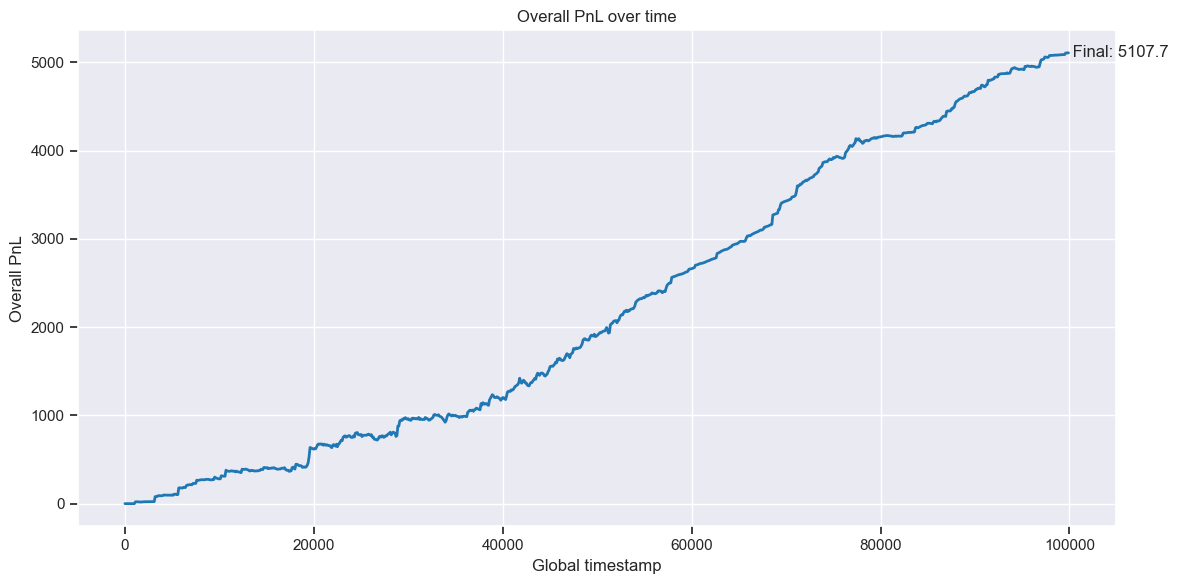

In [57]:
path = "data/version_4.log"
with open(path, "r", encoding="utf-8") as f:
    raw_v4 = json.load(f)

df_performance_v4 = pd.read_csv(StringIO(raw_v4["activitiesLog"]), sep=";")

df_performance_v4["global_timestamp"] = (df_performance_v4["day"] - df_performance_v4["day"].min()) * DAY_LENGTH + df_performance_v4["timestamp"]

overall_pnl = (
    df_performance_v4.groupby("global_timestamp", as_index=False)["profit_and_loss"]
      .sum()
      .sort_values(["global_timestamp"])
)

plt.figure(figsize=(12, 6))
plt.plot(overall_pnl["global_timestamp"], overall_pnl["profit_and_loss"], linewidth=2)

plt.title("Overall PnL over time")
plt.xlabel("Global timestamp")
plt.ylabel("Overall PnL")
plt.grid(True)

final_pnl = overall_pnl["profit_and_loss"].iloc[-1]
plt.text(
    overall_pnl["global_timestamp"].iloc[-1],
    final_pnl,
    f" Final: {final_pnl:.1f}",
    va="center"
)

plt.tight_layout()
plt.show()

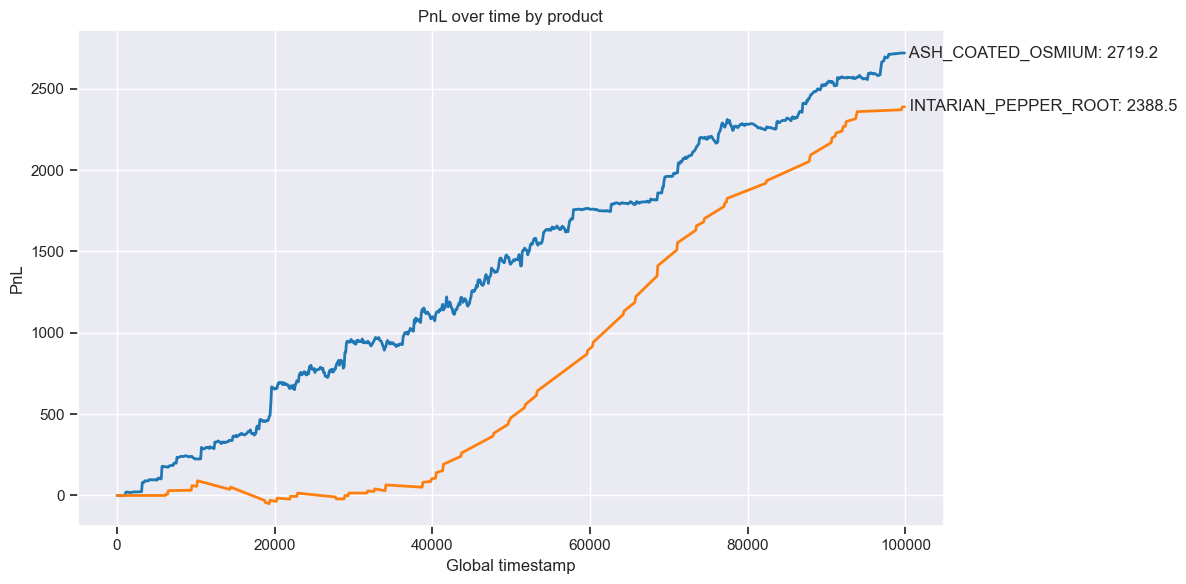

In [58]:
plt.figure(figsize=(12, 6))

for product, g in df_performance_v4.groupby("product"):
    g = g.sort_values("global_timestamp")
    plt.plot(g["global_timestamp"], g["profit_and_loss"], linewidth=2, label=product)
    plt.text(
        g["global_timestamp"].iloc[-1],
        g["profit_and_loss"].iloc[-1],
        f" {product}: {g['profit_and_loss'].iloc[-1]:.1f}",
        va="center"
    )

plt.title("PnL over time by product")
plt.xlabel("Global timestamp")
plt.ylabel("PnL")
plt.grid(True)
plt.tight_layout()
plt.show()

Trading activity:

In [59]:
df_trades_v4 = pd.DataFrame(raw_v4['tradeHistory'])

df_trades_v4['signed_qty']=np.where(df_trades_v4['buyer']=='SUBMISSION', df_trades_v4['quantity'],
                                     np.where(df_trades_v4['seller']=='SUBMISSION', -df_trades_v4['quantity'], 0))
df_trades_v4['cashflow']= -df_trades_v4['signed_qty']*df_trades_v4['price'] 

metrics = {}

for prod,g in df_trades_v4.groupby('symbol'):
    buys = g[g['signed_qty']>0]
    sells = g[g['signed_qty']<0]
    pos = g['signed_qty'].cumsum()
    metrics[prod]={
        'fills': len(g),
        'buy_fills': len(buys),
        'sell_fills': len(sells),
        'buy_qty': buys['signed_qty'].sum(),
        'sell_qty': -sells['signed_qty'].sum(),
        'avg_buy_px': np.average(buys['price'], weights=buys['signed_qty']) if len(buys) else np.nan,
        'avg_sell_px': np.average(sells['price'], weights=-sells['signed_qty']) if len(sells) else np.nan,
        'end_pos': g['signed_qty'].sum(),
        'max_abs_pos': pos.abs().max(),
        'cash_pnl': g['cashflow'].sum(),
    }

pd.DataFrame(metrics).T

,fills,buy_fills,sell_fills,buy_qty,sell_qty,avg_buy_px,avg_sell_px,end_pos,max_abs_pos,cash_pnl
ASH_COATED_OSMIUM,82.0,38.0,35.0,218.0,215.0,9992.935780,10005.446512,3.0,62.0,-27289.0
INTARIAN_PEPPER_ROOT,48.0,26.0,20.0,119.0,114.0,12043.840336,12062.333333,5.0,47.0,-58111.0


Drawdowns:

In [60]:
df_performance_v4_wide = df_performance_v4.pivot(index='timestamp', columns='product', values='profit_and_loss').sort_index()
df_performance_v4_wide['total']=df_performance_v4_wide.sum(axis=1)
dd = df_performance_v4_wide['total'] - df_performance_v4_wide['total'].cummax()

for prod in metrics:

    metrics[prod]['limit_utilization']=metrics[prod]['max_abs_pos']/80

dds={}

for col in ['ASH_COATED_OSMIUM','INTARIAN_PEPPER_ROOT','total']:

    s=df_performance_v2_wide[col]
    dd=s-s.cummax()

    dds[col]={
        'final': s.iloc[-1],
        'max': s.max(),
        'min': s.min(),
        'max_drawdown': dd.min(),
        'time_of_mdd': dd.idxmin(),
    }

pd.DataFrame(dds).T

,final,max,min,max_drawdown,time_of_mdd
ASH_COATED_OSMIUM,2719.156250,2719.406250,0.000000,-107.375,42800.0
INTARIAN_PEPPER_ROOT,1865.900391,1865.900391,-81.109375,-171.500,38700.0
total,4585.056641,4585.155273,0.000000,-99.375,33900.0


### 6.7 Conclusion

Version 4 is the preferred final specification.

The reason is not simply that it produces the highest final PnL, though it does. Final Pepper PnL rises further to about **2388.5**, bringing total PnL to roughly **5107.7**, while Osmium remains stable at about **2719.2**. More importantly, Version 4 is the first version that addresses the root cause of Pepper underperformance in a coherent way. It combines the correct fair value model with an inventory policy that is consistent with an upward drifting product.

Across all four versions, the Osmium component remains reliable because the original regime analysis was already correct: a fixed anchor, strong top of book signals and passive spread capture with inventory control. The development effort matters mainly for Pepper. The version history shows a clear progression from conservative fair value trading to regime aware inventory management.

The main lesson from the notebook is therefore broader than the final code choice. Correct fair value estimation is necessary, but it is not sufficient. A strategy also needs execution and inventory logic that match the underlying price regime of the product it is trading.